# Swahili Horticulture Question Answering: full pipeline notebook

Domain-specific QA in Swahili (horticulture). The system retrieves a passage from farming manuals, extracts the answer with a fine-tuned reader, and declines out-of-domain questions.

**This single notebook is the code of record.** It is built phase by phase. Every number reported in the README/report is computed here and saved to `results/`.

| Part | Phase | Status |
|---|---|---|
| 0. Setup | - | done |
| 1. Data: download, clean, explore, split | 2 | done |
| 2. Baselines (BM25 + rule-based reader + OOD rule + zero-shot XLM-R-SQuAD2) | 3 | **this version** |
| 3. Experiments: E1 top-k reading, E2 refusal signals, E3 head-only fine-tune, E4 full fine-tune of pretrained models (Colab), **E5 GRU / LSTM / Transformer trained from scratch, E6 deployed model** | 4 | **this version** |
| 4. Final evaluation + error analysis of the deployed model | 5 | **this version** |
| 5. Export `app/model.pkl`, test the NumPy app code | 6 | **this version** |

**How to run:** locally from the repo (`notebooks/` folder) or on Google Colab (free T4). Run all cells top to bottom. Part 1 needs no GPU and no extra installs. Re-running is safe: files already downloaded are reused, and all randomness is seeded.

## Where the course topics appear in this notebook
| Course topic | Where it is used |
|---|---|
| Tokenization | Part 1.3 and 1.4 (word tokens); Part 3.5b (word-level vocabulary built from training text); Part 2.5 and 3.1 (sub-word tokens of the pretrained model) |
| Word embeddings | Part 3.5b: every word gets a learned 128-number vector, plus segment and position embeddings |
| RNN, LSTM, GRU | Part 3.5b: **BiGRU and BiLSTM readers written and trained from scratch** |
| Attention | Part 3.5b: question attention layer in the RNN readers; self-attention inside the Transformer |
| Transformers | Part 3.5b: **a Transformer encoder built and trained from scratch**; Parts 2.5, 3.4, 3.5 use a pretrained Transformer (XLM-R) as a comparison |
| Transfer learning and fine-tuning | Part 3.4 (head only) and 3.5 (all layers) |
| Retrieval | Part 2.1 (BM25 from scratch) |
| Evaluation | EM and F1, recall@k, MRR, AUROC, bootstrap confidence intervals, error analysis (Parts 2 to 4) |
| Deployment | Part 5: the model is exported to `app/model.pkl` and served by a Streamlit app |

## Part 0. Setup
Imports, one global random seed, and the folder layout. The notebook finds the repo root itself: if it is run from `notebooks/` it moves up one level; on Colab it mounts your Google Drive and uses the folder set in `COLAB_PROJECT_DIR`. The notebook creates only `data/` and `results/` there (nothing else), so nothing is lost when the session ends.

In [1]:
import collections, hashlib, json, random, re, statistics, time, unicodedata, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42                      # one seed for every random choice in this notebook
random.seed(SEED); np.random.seed(SEED)

import sys
# Folder in YOUR Google Drive that holds this notebook. On Colab, data/ and results/ are created inside it, so nothing is lost
# when the session ends. Change this path if you keep the notebook somewhere else.
COLAB_PROJECT_DIR = "/content/drive/MyDrive/ML_technique_1/Summative"
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")                       # a pop-up asks you to allow access to your Drive
    ROOT = Path(COLAB_PROJECT_DIR); ROOT.mkdir(parents=True, exist_ok=True)
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW, PROC = ROOT / "data" / "raw", ROOT / "data" / "processed"
RES, FIG = ROOT / "results" / "data", ROOT / "results" / "figures"
for p in (RAW, PROC, RES, FIG):
    p.mkdir(parents=True, exist_ok=True)

def save_json(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")

def write_jsonl(rows, path):
    with open(path, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

def read_jsonl(path):
    with open(path, encoding="utf-8-sig") as f:
        return [json.loads(line) for line in f if line.strip()]

print("repo root:", ROOT)

Mounted at /content/drive
repo root: /content/drive/MyDrive/ML_technique_1/Summative


In [2]:
# The XLM-R tokenizer needs the `sentencepiece` package. Colab usually has it; this installs it only if it is missing.
import importlib.util, subprocess, sys
if importlib.util.find_spec("sentencepiece") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sentencepiece"], check=True)
print("sentencepiece available:", importlib.util.find_spec("sentencepiece") is not None)

sentencepiece available: True


## Part 1. Data (Phase 2)

### 1.1 Sources
| Role | Dataset | Where | License |
|---|---|---|---|
| Train / validation / test | *Swahili Question-Answering Dataset for Horticulture* (Lubawa, 2024) | Harvard Dataverse, DOI 10.7910/DVN/SORRLR | CC0 1.0 |
| Out-of-domain questions | AfriQA, Swahili queries (Ogundepo et al., 2023) | github.com/masakhane-io/afriqa | CC BY-NC 4.0 (non-commercial; fine for coursework) |
| Optional extra out-of-domain | KenSwQuAD (Wanjawa et al.) | Harvard Dataverse, DOI 10.7910/DVN/OTL0LM, CC BY 4.0 | Requires a **guestbook form**, so it must be downloaded by hand, not by this notebook |

Why AfriQA for out-of-domain: its Swahili questions are real, human-written, general-knowledge questions (music, science, people), so they should *not* be answerable from horticulture manuals.

In [3]:
HORTI_DOI = "doi:10.7910/DVN/SORRLR"
AFRIQA_URL = "https://github.com/masakhane-io/afriqa/raw/main/data/queries/swa/queries.afriqa.swa.en.{split}.json"

def fetch(url, dest, tries=5, timeout=60):
    """Download with retries (GitHub and Dataverse sometimes time out). Returns True on success."""
    dest = Path(dest)
    if dest.exists() and dest.stat().st_size > 0:
        return True                                   # already downloaded, reuse
    for attempt in range(tries):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=timeout) as r:
                dest.write_bytes(r.read())
            return True
        except Exception as e:
            print(f"  attempt {attempt + 1}/{tries} failed for {dest.name}: {e}")
            time.sleep(2 ** attempt)
    return False

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

download_log = {}

# --- horticulture JSON: look up its file id through the Dataverse API, then download it
meta_url = f"https://dataverse.harvard.edu/api/datasets/:persistentId/versions/:latest?persistentId={HORTI_DOI}"
meta = json.load(urllib.request.urlopen(urllib.request.Request(meta_url, headers={"User-Agent": "Mozilla/5.0"}), timeout=60))
files = {f["label"]: f for f in meta["data"]["files"]}
lic = meta["data"].get("license", {})
file_id = files["hortidata.json"]["dataFile"]["id"]
ok = fetch(f"https://dataverse.harvard.edu/api/access/datafile/{file_id}?format=original", RAW / "hortidata.json")
assert ok, "could not download the horticulture dataset"
download_log["hortidata.json"] = {"source": HORTI_DOI, "license": lic.get("name"), "bytes": (RAW / "hortidata.json").stat().st_size,
                                  "sha256": sha256(RAW / "hortidata.json")}

# --- AfriQA Swahili question files
for split in ("train", "dev", "test"):
    name = f"afriqa_swa_{split}.jsonl"
    ok = fetch(AFRIQA_URL.format(split=split), RAW / name)
    download_log[name] = ({"source": AFRIQA_URL.format(split=split), "license": "CC BY-NC 4.0",
                           "bytes": (RAW / name).stat().st_size, "sha256": sha256(RAW / name)} if ok else {"status": "DOWNLOAD FAILED"})

save_json(download_log, RES / "download_log.json")
print(json.dumps(download_log, indent=2))

{
  "hortidata.json": {
    "source": "doi:10.7910/DVN/SORRLR",
    "license": "CC0 1.0",
    "bytes": 2656892,
    "sha256": "35ae1579fea70011070f71188f530e1ebdfe4d3c9aac555ffb9ff17adf4d7a4d"
  },
  "afriqa_swa_train.jsonl": {
    "source": "https://github.com/masakhane-io/afriqa/raw/main/data/queries/swa/queries.afriqa.swa.en.train.json",
    "license": "CC BY-NC 4.0",
    "bytes": 114297,
    "sha256": "d5d03c1bf62de83e1dcd951483717773c02b1c2d6fd7fdaaa750bcc7c0751776"
  },
  "afriqa_swa_dev.jsonl": {
    "source": "https://github.com/masakhane-io/afriqa/raw/main/data/queries/swa/queries.afriqa.swa.en.dev.json",
    "license": "CC BY-NC 4.0",
    "bytes": 115373,
    "sha256": "cdc61a37956592318f98c8d6ca7cc3908bfbc5bf2cb30af4c13203c4f446a054"
  },
  "afriqa_swa_test.jsonl": {
    "source": "https://github.com/masakhane-io/afriqa/raw/main/data/queries/swa/queries.afriqa.swa.en.test.json",
    "license": "CC BY-NC 4.0",
    "bytes": 87689,
    "sha256": "0804e99d130a7d9357139686db1957a

### 1.2 Load and inspect the raw horticulture data
The file is in SQuAD v1 format: each record has a question, the passage (`context`), and the answer text with its character position (`answer_start`).

In [4]:
raw = json.loads((RAW / "hortidata.json").read_text(encoding="utf-8"))
print("raw records:", len(raw))
print("fields:", list(raw[0].keys()))
ex = raw[0]
print("\nexample question:", ex["question"])
print("example answer  :", ex["answers"])
print("passage start   :", ex["context"][:200], "...")

raw records: 2231
fields: ['id', 'context', 'question', 'answers']

example question: Maeneo gani yanastawisha vizuri tunda la tufaa?
example answer  : {'text': ['nyanda za juu'], 'answer_start': [233]}
passage start   : KILIMO CHA TUFAA. UTANGULIZI. Tufaa ni tunda moja maarufu duniani ambalo hupendwa kuliwa na watu wa jamii zote, hii inatokana na utamu wake pamoja na faida za kiafya zinazopatikana kwa kula matufaa. M ...


### 1.3 Cleaning
Every step logs how many records go in and out, so the report can show exact before/after counts.

Rules and why:
1. **Normalize question text** (Unicode NFC, trim, collapse repeated spaces). Stray whitespace makes identical questions look different. We do **not** touch passages or answers: changing the passage would shift the character offsets of the answers.
2. **Drop empty questions/answers.**
3. **Check answer alignment**: `context[answer_start : answer_start + len(answer)]` must equal the answer text. A misaligned answer would teach the model wrong spans. Misaligned records are dropped.
4. **Drop duplicates**: same question on the same passage. Duplicates in train and test would inflate scores.

In [5]:
cleaning_log = []
def log_step(step, desc, before, after, changed=0):
    cleaning_log.append({"step": step, "description": desc, "records_before": before, "records_after": after, "records_modified": changed})

records = []
for r in raw:                       # flatten: keep one answer per record (checked below that this holds)
    assert len(r["answers"]["text"]) == 1 and len(r["answers"]["answer_start"]) == 1
    records.append({"id": r["id"], "context": r["context"], "question": r["question"],
                    "answer": r["answers"]["text"][0], "answer_start": r["answers"]["answer_start"][0]})
n0 = len(records)
log_step(0, "raw records (one answer each)", n0, n0)

# step 1: normalize question text
changed = 0
for r in records:
    q = " ".join(unicodedata.normalize("NFC", r["question"]).split())
    changed += q != r["question"]
    r["question"] = q
log_step(1, "normalize question text (NFC, trim, collapse spaces)", len(records), len(records), changed)

# step 2: drop empties
before = len(records)
records = [r for r in records if r["question"].strip() and r["answer"].strip()]
log_step(2, "drop empty question or answer", before, len(records))

# step 3: answer alignment
def aligned(r):
    s, a = r["answer_start"], r["answer"]
    return r["context"][s:s + len(a)] == a
before = len(records)
records = [r for r in records if aligned(r)]
log_step(3, "drop records whose answer is not at answer_start in the passage", before, len(records))

# step 4: duplicates (same question on same passage); keep the first by id
before, seen, kept = len(records), set(), []
dups_removed = []
for r in sorted(records, key=lambda r: r["id"]):
    key = (r["question"].lower(), r["context"])
    if key in seen:
        dups_removed.append(r["id"]); continue
    seen.add(key); kept.append(r)
records = kept
log_step(4, "drop duplicate (question, passage) pairs, keep first", before, len(records))

# a stable passage id: first 10 hex chars of the SHA-1 of the passage text
for r in records:
    r["pid"] = hashlib.sha1(r["context"].encode("utf-8")).hexdigest()[:10]

clean_df = pd.DataFrame(cleaning_log)
clean_df.to_csv(RES / "cleaning_log.csv", index=False)
print("duplicate record ids removed:", dups_removed)
clean_df

duplicate record ids removed: [91, 94, 647, 914, 933, 1164]


,step,description,records_before,records_after,records_modified
0,0,raw records (one answer each),2231,2231,0
1,1,"normalize question text (NFC, trim, collapse s...",2231,2231,2
2,2,drop empty question or answer,2231,2231,0
3,3,drop records whose answer is not at answer_sta...,2231,2231,0
4,4,"drop duplicate (question, passage) pairs, keep...",2231,2225,0


In [6]:
write_jsonl(records, PROC / "horti_clean.jsonl")
df = pd.DataFrame(records)
print("clean records:", len(df), "| unique passages:", df["pid"].nunique(), "| questions per passage (mean):", round(len(df) / df["pid"].nunique(), 2))

clean records: 2225 | unique passages: 307 | questions per passage (mean): 7.25


### 1.4 Exploratory analysis
Tokenization here is only for counting statistics: a "word" is letters/digits plus internal apostrophes, so Swahili words like *ng'ombe* stay in one piece. (The model itself will use its own subword tokenizer later.)

In [7]:
WORD = re.compile(r"\w+(?:'\w+)*", re.UNICODE)
words = lambda s: WORD.findall(s.lower())

passages_df = df.drop_duplicates("pid")[["pid", "context"]].copy()
passages_df["n_words"] = passages_df["context"].map(lambda s: len(words(s)))
df["q_words"] = df["question"].map(lambda s: len(words(s)))
df["a_words"] = df["answer"].map(lambda s: len(words(s)))
df["a_pos"] = df["answer_start"] / df["context"].str.len()        # relative position of the answer in its passage

def describe(s):
    return {"min": int(s.min()), "median": float(s.median()), "mean": round(float(s.mean()), 1), "max": int(s.max())}
stats = {"passage_words": describe(passages_df["n_words"]), "question_words": describe(df["q_words"]), "answer_words": describe(df["a_words"])}

# vocabulary statistics over the unique passages
tok = [w for c in passages_df["context"] for w in words(c)]
counts = collections.Counter(tok)
stats["vocabulary"] = {"passage_tokens": len(tok), "passage_types": len(counts),
                       "type_token_ratio": round(len(counts) / len(tok), 3),
                       "hapax_share_of_types": round(sum(v == 1 for v in counts.values()) / len(counts), 3)}
print(json.dumps(stats, indent=2))

{
  "passage_words": {
    "min": 75,
    "median": 150.0,
    "mean": 152.7,
    "max": 289
  },
  "question_words": {
    "min": 3,
    "median": 9.0,
    "mean": 9.5,
    "max": 19
  },
  "answer_words": {
    "min": 1,
    "median": 3.0,
    "mean": 3.5,
    "max": 23
  },
  "vocabulary": {
    "passage_tokens": 46869,
    "passage_types": 5368,
    "type_token_ratio": 0.115,
    "hapax_share_of_types": 0.53
  }
}


{'gani': 1269, 'nini': 138, 'nani': 4, 'lini': 34, 'wapi': 26, 'vipi': 23, 'ngapi': 103, 'kwa nini': 14, 'je': 1080, 'none of these': 365}


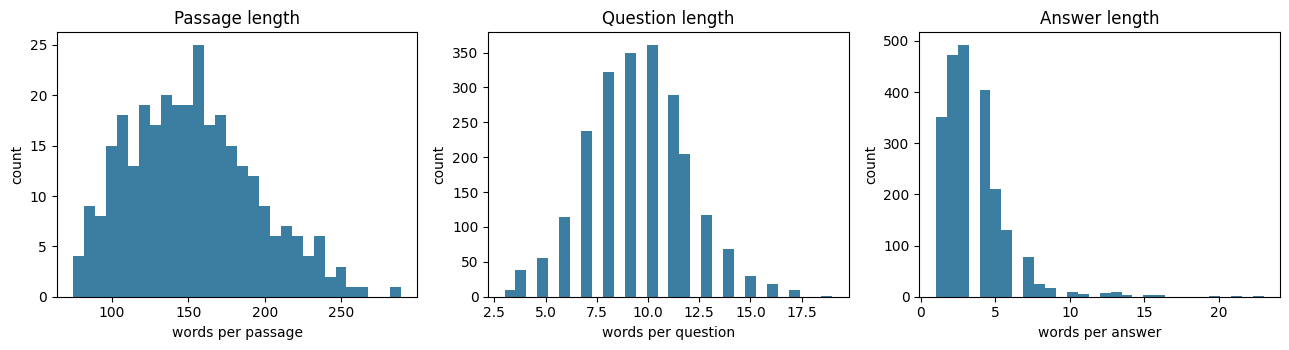

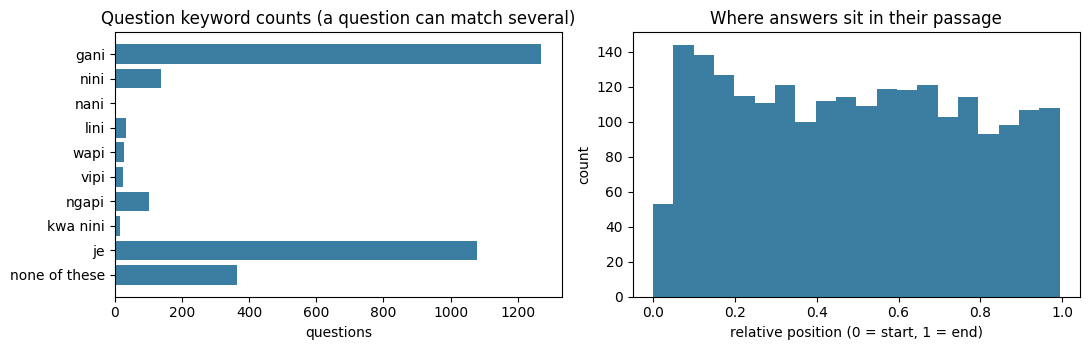

In [8]:
# Question types. These keyword labels are my reading of common Swahili question words
# (gani=which/what, nini=what, nani=who, lini=when, wapi=where, vipi=how, ngapi=how many, kwa nini=why).
# Please check them with a Swahili speaker or dictionary before quoting them in the report.
QWORDS = {"gani": r"\bgani\b", "nini": r"\bnini\b", "nani": r"\bnani\b", "lini": r"\blini\b", "wapi": r"\bwapi\b",
          "vipi": r"\bvipi\b", "ngapi": r"\bngapi\b", "kwa nini": r"\bkwa nini\b", "je": r"^je\b"}
qtype = {k: int(df["question"].str.lower().str.contains(p, regex=True).sum()) for k, p in QWORDS.items()}
qtype["none of these"] = int((~pd.concat([df["question"].str.lower().str.contains(p, regex=True) for p in QWORDS.values()], axis=1).any(axis=1)).sum())
stats["question_keyword_counts"] = qtype
print(qtype)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for a, (col, title, xlabel) in zip(ax, [("n_words", "Passage length", "words per passage"), ("q_words", "Question length", "words per question"), ("a_words", "Answer length", "words per answer")]):
    src = passages_df if col == "n_words" else df
    a.hist(src[col], bins=30, color="#3b7ea1"); a.set_title(title); a.set_xlabel(xlabel); a.set_ylabel("count")
plt.tight_layout(); plt.savefig(FIG / "eda_length_distributions.png", dpi=150); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].barh(list(qtype.keys())[::-1], list(qtype.values())[::-1], color="#3b7ea1"); ax[0].set_title("Question keyword counts (a question can match several)"); ax[0].set_xlabel("questions")
ax[1].hist(df["a_pos"], bins=20, color="#3b7ea1"); ax[1].set_title("Where answers sit in their passage"); ax[1].set_xlabel("relative position (0 = start, 1 = end)"); ax[1].set_ylabel("count")
plt.tight_layout(); plt.savefig(FIG / "eda_question_types_answer_position.png", dpi=150); plt.show()

### 1.5 Noise and quality checks
Two things that could silently inflate our scores or hide problems:

1. **Near-duplicate passages.** The 307 passages come from 52 manuals, and some passages overlap (e.g. the same disease described twice). If one copy is in train and the other in test, the model sees test text during training. We measure overlap as the share of 8-word sequences that two passages have in common (relative to the shorter passage).
2. **Answer length / position outliers**, to see whether any gold answers are suspiciously long.

In [9]:
N_GRAM, OVERLAP_THRESHOLD = 8, 0.30     # threshold chosen conservatively; see docs/DECISIONS.md (D13)

def ngrams(text, n=N_GRAM):
    w = words(text)
    return {" ".join(w[i:i + n]) for i in range(len(w) - n + 1)}

pids = passages_df["pid"].tolist()
G = {p: ngrams(c) for p, c in zip(passages_df["pid"], passages_df["context"])}
near_pairs = []
for i in range(len(pids)):
    for j in range(i + 1, len(pids)):
        a, b = G[pids[i]], G[pids[j]]
        if a and b:
            ov = len(a & b) / min(len(a), len(b))
            if ov > OVERLAP_THRESHOLD:
                near_pairs.append((pids[i], pids[j], round(ov, 2)))
print(f"passage pairs sharing >{OVERLAP_THRESHOLD:.0%} of their {N_GRAM}-grams: {len(near_pairs)}")
for p, q, ov in near_pairs:
    print(f"  {p} ~ {q}  overlap={ov}")

longest = df.sort_values("a_words", ascending=False).head(5)[["id", "a_words", "question", "answer"]]
longest["answer"] = longest["answer"].str.slice(0, 90)
longest

passage pairs sharing >30% of their 8-grams: 6
  59499a26af ~ 7318d708b8  overlap=0.6
  1f5ce43117 ~ 7318d708b8  overlap=0.36
  1f5ce43117 ~ b801589e3f  overlap=0.42
  3ca3154215 ~ 3a24d1bfa7  overlap=0.86
  1f9afd7808 ~ 18e2a51974  overlap=1.0
  3925b41e73 ~ 9a61889077  overlap=0.84


,id,a_words,question,answer
717,738,23,Vitu gani hujumuisha mbinu zenye kuongeza tham...,"Kuandaa shamba, Matumizi ya mbegu bora, Kupali..."
1201,1226,21,Mifano ya dawa za kukabiliana na bakajani tang...,"Champ Dry Prill, Champ Formula 2, Copper-Count..."
1216,1241,20,Mifano ya dawa mrututu zenye uwezo wa kukabili...,"Champ Dry Prill, Champ Formula 2, Copper-Count..."
1246,1271,16,"Je, dawa gani zenye kiambato cha klorothalonil...","Bravo 720/Ensign, Bravo Ultrex, Bravo Weather ..."
1218,1243,16,Mifano ya dawa za kukabiliana na bakajani chel...,"Cuprofix MZ Disperss, Dithane, Gavel, Maneb 75..."


### 1.6 Train / validation / test split (by passage group)
**Why not split randomly by question?** About 7 questions share each passage. A random question split would put the same passage in train and test, and the reader could score well by memorizing passages.

**What we do instead:**
1. Join near-duplicate passages (from 1.5) into **groups** with union-find, so overlapping passages always stay together.
2. Shuffle the groups with the fixed seed and assign each group to whichever split is currently furthest below its target share (70% / 15% / 15% of *questions*).
3. Assert that no passage and no group appears in more than one split.

In [10]:
# union-find over passages joined by a near-duplicate edge
parent = {p: p for p in pids}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
for p, q, _ in near_pairs:
    parent[find(p)] = find(q)

group_of = {p: find(p) for p in pids}
df["group"] = df["pid"].map(group_of)
groups = df.groupby("group").size().to_dict()          # group -> number of questions
print("passages:", len(pids), "| groups after merging near-duplicates:", len(groups))

TARGET = {"train": 0.70, "val": 0.15, "test": 0.15}
rng = random.Random(SEED)
order = sorted(groups)                                  # sort first so the shuffle is reproducible
rng.shuffle(order)
assigned = {s: [] for s in TARGET}
n_q = {s: 0 for s in TARGET}
total_q = sum(groups.values())
for g in order:
    # deficit = how far below its target share each split currently is
    split = max(TARGET, key=lambda s: TARGET[s] - n_q[s] / total_q)
    assigned[split].append(g); n_q[split] += groups[g]
split_of_group = {g: s for s, gs in assigned.items() for g in gs}
df["split"] = df["group"].map(split_of_group)

# --- leakage checks (the notebook stops here if any fails)
sets = {s: set(df.loc[df["split"] == s, "pid"]) for s in TARGET}
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    assert not (sets[a] & sets[b]), f"passage leakage between {a} and {b}"
gsets = {s: set(df.loc[df["split"] == s, "group"]) for s in TARGET}
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    assert not (gsets[a] & gsets[b]), f"group leakage between {a} and {b}"
qtext = {s: set(df.loc[df["split"] == s, "question"].str.lower()) for s in TARGET}
shared_questions = {f"{a}&{b}": len(qtext[a] & qtext[b]) for a, b in [("train", "val"), ("train", "test"), ("val", "test")]}
print("leakage checks passed: no passage or group in more than one split")
print("identical question strings shared across splits (informational):", shared_questions)

split_summary = []
for s in TARGET:
    d = df[df["split"] == s]
    split_summary.append({"split": s, "questions": len(d), "share_of_questions": round(len(d) / len(df), 3),
                          "passages": d["pid"].nunique(), "groups": d["group"].nunique()})
split_df = pd.DataFrame(split_summary)
split_df.to_csv(RES / "split_summary.csv", index=False)
split_df

passages: 307 | groups after merging near-duplicates: 301
leakage checks passed: no passage or group in more than one split
identical question strings shared across splits (informational): {'train&val': 0, 'train&test': 0, 'val&test': 0}


,split,questions,share_of_questions,passages,groups
0,train,1560,0.701,219,213
1,val,330,0.148,45,45
2,test,335,0.151,43,43


In [11]:
cols = ["id", "pid", "group", "question", "answer", "answer_start", "context"]
for s in TARGET:
    write_jsonl(df.loc[df["split"] == s, cols].to_dict("records"), PROC / f"horti_{s}.jsonl")

# The retrieval corpus is ALL passages (retrieval needs the full collection to search; the retriever is
# not trained on test questions). Each passage keeps its split label so we can report both ways later.
corpus = passages_df.merge(df.drop_duplicates("pid")[["pid", "group", "split"]], on="pid")
write_jsonl(corpus[["pid", "group", "split", "context"]].to_dict("records"), PROC / "passages.jsonl")

save_json({"seed": SEED, "target_shares": TARGET, "ngram": N_GRAM, "overlap_threshold": OVERLAP_THRESHOLD,
           "near_duplicate_pairs": near_pairs, "shared_question_strings": shared_questions,
           "question_ids": {s: sorted(df.loc[df["split"] == s, "id"].tolist()) for s in TARGET}}, RES / "split_manifest.json")
print("saved: horti_train/val/test.jsonl, passages.jsonl, split_manifest.json")

saved: horti_train/val/test.jsonl, passages.jsonl, split_manifest.json


In [12]:
# Vocabulary shift: what fraction of validation/test tokens never appear in the training text?
train_text = " ".join(df[df["split"] == "train"]["context"].drop_duplicates().tolist() + df[df["split"] == "train"]["question"].tolist())
train_vocab = set(words(train_text))
oov = {}
for s in ("val", "test"):
    qtok = [w for q in df[df["split"] == s]["question"] for w in words(q)]
    ctok = [w for c in df[df["split"] == s]["context"].drop_duplicates() for w in words(c)]
    oov[s] = {"question_oov_token_rate": round(sum(w not in train_vocab for w in qtok) / len(qtok), 3),
              "passage_oov_token_rate": round(sum(w not in train_vocab for w in ctok) / len(ctok), 3)}
stats["oov_vs_train"] = oov
print(json.dumps(oov, indent=2))

{
  "val": {
    "question_oov_token_rate": 0.052,
    "passage_oov_token_rate": 0.097
  },
  "test": {
    "question_oov_token_rate": 0.037,
    "passage_oov_token_rate": 0.083
  }
}


### 1.7 Out-of-domain question set
Used later to test whether the system refuses questions it should not answer.

- **Source:** AfriQA Swahili questions. We use only the *questions* (no passages are needed: the test is whether the system answers when it should not).
- **Validation vs test:** AfriQA `dev` questions tune the refusal threshold; AfriQA `test` questions give the final out-of-domain number. If `test` could not be downloaded, we fall back to `train` and say so.
- **Cleaning:** normalize text, drop empties and duplicates, drop questions that also appear in the horticulture data.
- **Contamination check:** some general questions might still be about farming. We flag questions containing common Swahili farming words and **exclude** them from the out-of-domain set, so a question the system could fairly answer is never counted as out-of-domain. The word list is hand-chosen, so please read the flagged questions printed below.

In [13]:
AGRI_TERMS = ["tunda", "matunda", "mmea", "mimea", "kilimo", "mazao", "zao", "shamba", "mashamba", "mbegu", "mboga", "miche",
              "mkulima", "wakulima", "kupanda", "kuvuna", "mbolea", "umwagiliaji"]   # hand-chosen; verify with a Swahili speaker
agri_re = re.compile(r"\b(" + "|".join(AGRI_TERMS) + r")\b", re.IGNORECASE)
horti_q = set(df["question"].str.lower())

def load_ood(path):
    rows, stats_ = [], collections.Counter()
    for r in read_jsonl(path):
        q = " ".join(unicodedata.normalize("NFC", r["question"]).split())
        stats_["raw"] += 1
        if not q: stats_["empty"] += 1; continue
        if q.lower() in horti_q: stats_["also_in_horticulture"] += 1; continue
        if agri_re.search(q): stats_["flagged_agri_terms"] += 1; rows.append(("FLAG", q, r)); continue
        rows.append(("OK", q, r))
    return rows, stats_

def build_ood(path):
    rows, st = load_ood(path)
    flagged = [q for tag, q, _ in rows if tag == "FLAG"]
    seen, out = set(), []
    for tag, q, r in rows:
        if tag == "FLAG" or q.lower() in seen:
            if tag == "OK": st["duplicate"] += 1
            continue
        seen.add(q.lower())
        out.append({"id": r["id"], "question": q, "english_translation": r.get("translated_question", ""), "source": "AfriQA-swa"})
    st["kept"] = len(out)
    return out, flagged, dict(st)

ood_files = {"val": RAW / "afriqa_swa_dev.jsonl", "test": RAW / "afriqa_swa_test.jsonl"}
ood_info = {}
if not ood_files["test"].exists():
    print("WARNING: AfriQA test file missing; using the AfriQA train file as the out-of-domain TEST set instead.")
    ood_files["test"] = RAW / "afriqa_swa_train.jsonl"
    ood_info["test_fallback_to_train"] = True
for s, path in ood_files.items():
    out, flagged, st = build_ood(path)
    write_jsonl(out, PROC / f"ood_{s}.jsonl")
    ood_info[s] = {"file": path.name, **st}
    print(f"\nOOD {s}: {st}")
    print("  flagged (excluded) questions for manual review:")
    for q in flagged: print("   -", q)
save_json(ood_info, RES / "ood_summary.json")


OOD val: {'raw': 417, 'flagged_agri_terms': 5, 'kept': 412}
  flagged (excluded) questions for manual review:
   - Nchi gani inayolima nyanya kwa wingi kama zao la biashara?
   - Zao kuu la biashara nchini Mexico ni lipi?
   - Zao la biashara la nchi ya Ufilipino ni lipi?
   - Je, soko kubwa kabisa ya matunda nchini Kenya inapatikana wapi?
   - Tunda la pamba liligunduliwa lini?

OOD test: {'raw': 302, 'flagged_agri_terms': 1, 'kept': 301}
  flagged (excluded) questions for manual review:
   - Mfumo wa umwagiliaji ulianza lini katika bara la Afrika?


### 1.8 Save the statistics
The numbers above are saved to `results/data/eda_stats.json`; `md_table` below is a small helper that later parts use to write tables as Markdown.

In [14]:
save_json(stats, RES / "eda_stats.json")

def md_table(frame):
    head = "| " + " | ".join(frame.columns) + " |\n|" + "---|" * len(frame.columns) + "\n"
    return head + "\n".join("| " + " | ".join(str(v) for v in row) + " |" for row in frame.itertuples(index=False))

### Phase 2 outputs
- `data/processed/`: `horti_clean.jsonl`, `horti_{train,val,test}.jsonl`, `passages.jsonl`, `ood_{val,test}.jsonl`
- `results/data/`: download log, cleaning log, split summary and manifest, EDA stats, OOD summary
- `results/figures/`: EDA figures

**Next (Phase 3):** baselines, in Part 2 below.

## Part 2. Baselines (Phase 3)

A baseline is the simplest reasonable system. Later, the fine-tuned model must beat it to justify its cost, and if it does not we must explain why. We build the baseline in three pieces that mirror the final system:

1. **Retriever: BM25** (written from scratch below, no library). Finds the passage for a question.
2. **Reader: a rule-based span picker** (no training). Chooses a short span inside a passage.
3. **Out-of-domain rule: a retrieval-score threshold.** Refuses a question when the best passage matches it poorly.

We evaluate the reader in two settings so we can separate the two sources of error:
- **Oracle passage:** the reader is given the *correct* passage. Measures the reader alone.
- **End-to-end:** the reader gets BM25's top-1 passage. Includes retrieval mistakes.

A third baseline, a **zero-shot pretrained multilingual QA model**, needs a model choice, so it is added after you approve one.

*Part 1 must have been run in this session first (this part reuses its `words`, `WORD`, `read_jsonl`, `write_jsonl`, `save_json` helpers).*

In [15]:
import math, string
from sklearn.metrics import roc_auc_score

BASE = ROOT / "results" / "baseline"; BASE.mkdir(parents=True, exist_ok=True)

train, val, test = (read_jsonl(PROC / f"horti_{s}.jsonl") for s in ("train", "val", "test"))
corpus = read_jsonl(PROC / "passages.jsonl")
pid_list = [p["pid"] for p in corpus]                    # row i of every BM25 score vector = passage pid_list[i]
ctx_of = {p["pid"]: p["context"] for p in corpus}
ood = {"val": read_jsonl(PROC / "ood_val.jsonl"), "test": read_jsonl(PROC / "ood_test.jsonl")}
print({"train": len(train), "val": len(val), "test": len(test), "passages": len(corpus), "ood_val": len(ood["val"]), "ood_test": len(ood["test"])})

{'train': 1560, 'val': 330, 'test': 335, 'passages': 307, 'ood_val': 412, 'ood_test': 301}


### 2.1 BM25 from scratch
For a query and a passage, BM25 adds up, over each query word *t* found in the passage:

`idf(t) * f * (k1 + 1) / (f + k1 * (1 - b + b * len / avglen))`

- `f` = how often *t* occurs in the passage. The `f / (f + k1 ...)` shape means repeating a word helps less and less (saturation).
- `idf(t)` = rarity of *t* across passages. A word in almost every passage (like *ya*) gets weight near 0; a rare word gets a high weight.
- `len / avglen` with `b` penalizes long passages (they contain more words by chance).
- We use the standard defaults `k1 = 1.5`, `b = 0.75` and do **not** tune them (the data is too small to tune safely).

Two extras for later use:
- **Normalized score** = score / (largest score a passage could possibly earn for this query, `sum idf(t) * (k1 + 1)`). It lies between 0 and 1 and says "what fraction of a perfect match did we get", so it is comparable across questions of different length. Query words never seen in any passage get the highest possible idf, so unfamiliar questions score low.

In [16]:
class BM25:
    """Okapi BM25 over a list of tokenized passages. Written out in full on purpose (see the formula above)."""
    def __init__(self, docs_tokens, k1=1.5, b=0.75):
        self.k1, self.b, self.N = k1, b, len(docs_tokens)
        self.doc_len = np.array([len(d) for d in docs_tokens], dtype=float)
        self.avgdl = self.doc_len.mean()
        self.tf = [collections.Counter(d) for d in docs_tokens]                 # term frequency per passage
        doc_freq = collections.Counter(t for d in docs_tokens for t in set(d))  # in how many passages each word occurs
        self.idf = {t: math.log(1 + (self.N - n + 0.5) / (n + 0.5)) for t, n in doc_freq.items()}   # never negative
        self.idf_unseen = math.log(1 + (self.N + 0.5) / 0.5)                    # idf of a word seen in no passage

    def idf_of(self, t):
        return self.idf.get(t, self.idf_unseen)

    def scores(self, q_tokens):
        s = np.zeros(self.N)
        for t in set(q_tokens):                                                  # each query word counted once
            if t not in self.idf:
                continue                                                         # unseen word: no passage contains it
            for i, tf in enumerate(self.tf):
                f = tf.get(t, 0)
                if f:
                    s[i] += self.idf[t] * f * (self.k1 + 1) / (f + self.k1 * (1 - self.b + self.b * self.doc_len[i] / self.avgdl))
        return s

    def normalized_top_score(self, q_tokens, raw_top):
        best_possible = sum(self.idf_of(t) * (self.k1 + 1) for t in set(q_tokens))
        return raw_top / best_possible if best_possible else 0.0

# Swahili words carry prefixes/suffixes (tufaa, matufaa, mitufaa). A crude "stemmer" keeps only the first k
# letters of each word so that related forms can match. k = None means exact words. We test several k.
def make_tokenizer(k):
    stem = (lambda w: w.lower()[:k]) if k else (lambda w: w.lower())
    return stem, (lambda text: [stem(w) for w in WORD.findall(text)])

def retrieval_eval(bm25, tok, questions, ks=(1, 3, 5, 10)):
    ranks, tops = [], []
    index = {p: i for i, p in enumerate(pid_list)}
    for q in questions:
        s = bm25.scores(tok(q["question"]))
        order = np.argsort(-s, kind="stable")
        ranks.append(1 + int(np.where(order == index[q["pid"]])[0][0]))        # position of the correct passage
    ranks = np.array(ranks)
    out = {f"recall@{k}": round(float((ranks <= k).mean()), 4) for k in ks}
    out["MRR"] = round(float((1 / ranks).mean()), 4)
    return out, ranks

STEM_LENGTHS = [None, 4, 5, 6]
bm25_by_k, tok_by_k, stem_by_k, rows = {}, {}, {}, []
for k in STEM_LENGTHS:
    stem, tok = make_tokenizer(k)
    stem_by_k[k], tok_by_k[k] = stem, tok
    bm25_by_k[k] = BM25([tok(p["context"]) for p in corpus])
    for name, qs in (("val", val), ("test", test)):
        res, _ = retrieval_eval(bm25_by_k[k], tok, qs)
        rows.append({"tokenizer": "exact words" if k is None else f"first {k} letters", "split": name, **res})
retr_df = pd.DataFrame(rows)
retr_df.to_csv(BASE / "retrieval_results.csv", index=False)
retr_df

,tokenizer,split,recall@1,recall@3,recall@5,recall@10,MRR
0,exact words,val,0.5394,0.7697,0.8697,0.9424,0.6781
1,exact words,test,0.4627,0.7104,0.8149,0.8925,0.6116
2,first 4 letters,val,0.5424,0.7273,0.8242,0.9121,0.6634
3,first 4 letters,test,0.4269,0.6657,0.7910,0.8955,0.5779
4,first 5 letters,val,0.5485,0.7727,0.8515,0.9394,0.6816
5,first 5 letters,test,0.4448,0.6955,0.8090,0.8866,0.5940
6,first 6 letters,val,0.5576,0.7879,0.8727,0.9455,0.6915
7,first 6 letters,test,0.4597,0.6955,0.8060,0.8925,0.6035


chosen on validation recall@1: first 6 letters


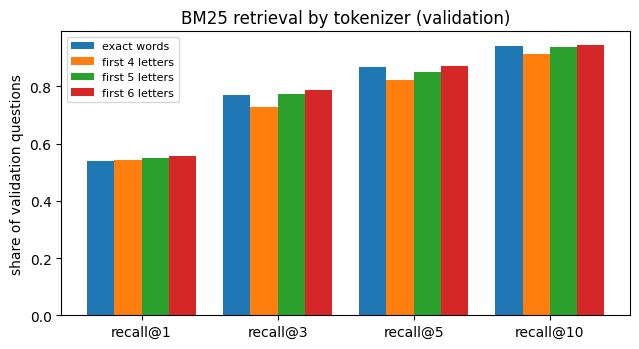

In [17]:
# Pick the tokenizer using VALIDATION only (never the test set), then report test for that choice.
val_rows = retr_df[retr_df["split"] == "val"]
best_name = val_rows.sort_values(["recall@1", "MRR"], ascending=False).iloc[0]["tokenizer"]
BEST_K = {("exact words" if k is None else f"first {k} letters"): k for k in STEM_LENGTHS}[best_name]
bm25, stem_word, tok = bm25_by_k[BEST_K], stem_by_k[BEST_K], tok_by_k[BEST_K]
print("chosen on validation recall@1:", best_name)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for j, name in enumerate(val_rows["tokenizer"]):
    ax.bar(np.arange(4) + j * 0.2, [val_rows.iloc[j][f"recall@{k}"] for k in (1, 3, 5, 10)], width=0.2, label=name)
ax.set_xticks(np.arange(4) + 0.3); ax.set_xticklabels(["recall@1", "recall@3", "recall@5", "recall@10"])
ax.set_ylabel("share of validation questions"); ax.set_title("BM25 retrieval by tokenizer (validation)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "baseline_retrieval_recall.png", dpi=150); plt.show()

### 2.2 Rule-based reader (no training)
Given a question and a passage:
1. **Pick the best sentence:** the sentence sharing the most (idf-weighted) words with the question.
2. **Pick a short window inside it:** slide a window of `W` words along the sentence. Skip windows that contain question words (the answer usually is not a repeat of the question). Score each window by how close it sits to the matched question words (`idf / (1 + distance)`), and return the best.

`W` is the only setting. We choose it on the **training** questions (oracle passage), then report validation and test.

Reference points that make the numbers interpretable:
- **Whole best sentence** as the answer (shows how much the window step helps).
- **Random window** of the same width inside the correct passage (the floor: what chance gives).

In [18]:
def normalize_answer(s):
    """SQuAD-style normalization: lowercase, remove punctuation (any Unicode 'P*' character), collapse spaces.
    (The English-article step of the original SQuAD script is skipped: it does not apply to Swahili.)"""
    s = "".join(ch for ch in s.lower() if not unicodedata.category(ch).startswith("P"))
    return " ".join(s.split())

def exact_match(pred, gold):
    return float(normalize_answer(pred) == normalize_answer(gold))

def f1_score(pred, gold):
    p, g = normalize_answer(pred).split(), normalize_answer(gold).split()
    if not p or not g:
        return float(p == g)
    common = sum((collections.Counter(p) & collections.Counter(g)).values())
    if common == 0:
        return 0.0
    precision, recall = common / len(p), common / len(g)
    return 2 * precision * recall / (precision + recall)

# sanity checks of the metric code (the notebook stops if these fail)
assert exact_match("Nyanda za juu.", "nyanda za juu") == 1.0
assert abs(f1_score("nyanda za juu sana", "nyanda za juu") - 2 * (3 / 4) * 1 / (3 / 4 + 1)) < 1e-9
assert f1_score("mbegu", "miche") == 0.0

SENT_SPLIT = re.compile(r"(?<=[.!?])\s+")
def split_sentences(context):
    return [s for s in SENT_SPLIT.split(context) if s.strip()] or [context]

def best_sentence(question, context):
    q = set(tok(question))
    best, best_score = None, -1.0
    for s in split_sentences(context):
        score = sum(bm25.idf_of(t) for t in set(tok(s)) & q)
        if score > best_score:
            best, best_score = s, score
    return best

def pick_window(question, sentence, W):
    surface = WORD.findall(sentence)                       # original-case words, used to build the answer text
    if len(surface) <= W:
        return " ".join(surface)
    stems = [stem_word(w) for w in surface]
    q = set(tok(question))
    hits = [i for i, t in enumerate(stems) if t in q]       # positions of question words in the sentence
    best, best_score = None, -1.0
    for start in range(len(surface) - W + 1):
        end = start + W - 1
        if any(start <= h <= end for h in hits):            # skip windows that repeat question words
            continue
        score = 0.0
        for h in hits:
            dist = start - h if h < start else h - end
            score += bm25.idf_of(stems[h]) / (1 + dist)
        if score > best_score:
            best, best_score = start, score
    if best is None:                                        # every window overlaps a question word: take the first
        best = 0
    return " ".join(surface[best:best + W])

def evaluate_reader(questions, W, passage_for):
    """Returns per-question predictions and mean EM / F1. passage_for(q) gives the passage text to read."""
    preds = []
    for q in questions:
        sent = best_sentence(q["question"], passage_for(q))
        preds.append(pick_window(q["question"], sent, W))
    em = float(np.mean([exact_match(p, q["answer"]) for p, q in zip(preds, questions)]))
    f1 = float(np.mean([f1_score(p, q["answer"]) for p, q in zip(preds, questions)]))
    return preds, round(em, 4), round(f1, 4)

oracle = lambda q: ctx_of[q["pid"]]
w_rows = []
for W in (2, 3, 4, 5, 6):
    _, em, f1 = evaluate_reader(train, W, oracle)
    w_rows.append({"W": W, "train_EM": em, "train_F1": f1})
w_df = pd.DataFrame(w_rows); w_df

,W,train_EM,train_F1
0,2,0.0071,0.0609
1,3,0.0064,0.0869
2,4,0.0064,0.1052
3,5,0.0032,0.1065
4,6,0.0013,0.1079


In [19]:
BEST_W = int(w_df.sort_values("train_F1", ascending=False).iloc[0]["W"])
print("window width chosen on training questions (oracle passage):", BEST_W)

# ---- retrieved top-1 passage for every question, and the ceiling "does the gold answer even appear in it?"
index = {p: i for i, p in enumerate(pid_list)}
def retrieve(question_text, k=1):
    s = bm25.scores(tok(question_text)); order = np.argsort(-s, kind="stable")[:k]
    return [pid_list[i] for i in order], float(s[order[0]])

def run_split(questions):
    top1 = [retrieve(q["question"])[0][0] for q in questions]
    return top1

rng = random.Random(SEED)
def random_window(context, W):
    words_ = WORD.findall(context); i = rng.randrange(max(1, len(words_) - W + 1)); return " ".join(words_[i:i + W])

results, predictions = {}, {}
for name, qs in (("val", val), ("test", test)):
    top1 = run_split(qs)
    retrieved_ctx = {q["id"]: ctx_of[p] for q, p in zip(qs, top1)}
    p_oracle, em_o, f1_o = evaluate_reader(qs, BEST_W, oracle)
    p_e2e, em_e, f1_e = evaluate_reader(qs, BEST_W, lambda q: retrieved_ctx[q["id"]])
    p_sent = [best_sentence(q["question"], ctx_of[q["pid"]]) for q in qs]
    p_rand = [random_window(ctx_of[q["pid"]], BEST_W) for q in qs]
    results[name] = {
        "n_questions": len(qs),
        "retrieval_recall@1": round(float(np.mean([p == q["pid"] for p, q in zip(top1, qs)])), 4),
        "answer_text_in_top1_passage": round(float(np.mean([normalize_answer(q["answer"]) in normalize_answer(retrieved_ctx[q["id"]]) for q in qs])), 4),
        "oracle_passage": {"EM": em_o, "F1": f1_o},
        "end_to_end_bm25_top1": {"EM": em_e, "F1": f1_e},
        "whole_best_sentence_oracle": {"EM": round(float(np.mean([exact_match(p, q["answer"]) for p, q in zip(p_sent, qs)])), 4),
                                       "F1": round(float(np.mean([f1_score(p, q["answer"]) for p, q in zip(p_sent, qs)])), 4)},
        "random_window_oracle": {"EM": round(float(np.mean([exact_match(p, q["answer"]) for p, q in zip(p_rand, qs)])), 4),
                                 "F1": round(float(np.mean([f1_score(p, q["answer"]) for p, q in zip(p_rand, qs)])), 4)},
    }
    predictions[name] = [{"id": q["id"], "question": q["question"], "gold_answer": q["answer"], "gold_pid": q["pid"], "retrieved_pid": p,
                          "retrieval_correct": p == q["pid"], "pred_oracle": a, "pred_end_to_end": b,
                          "f1_oracle": round(f1_score(a, q["answer"]), 3), "f1_end_to_end": round(f1_score(b, q["answer"]), 3)}
                         for q, p, a, b in zip(qs, top1, p_oracle, p_e2e)]
    write_jsonl(predictions[name], BASE / f"predictions_{name}.jsonl")
print(json.dumps(results, indent=2))

window width chosen on training questions (oracle passage): 6
{
  "val": {
    "n_questions": 330,
    "retrieval_recall@1": 0.5576,
    "answer_text_in_top1_passage": 0.5818,
    "oracle_passage": {
      "EM": 0.0,
      "F1": 0.1051
    },
    "end_to_end_bm25_top1": {
      "EM": 0.0,
      "F1": 0.0706
    },
    "whole_best_sentence_oracle": {
      "EM": 0.0,
      "F1": 0.1185
    },
    "random_window_oracle": {
      "EM": 0.0,
      "F1": 0.0474
    }
  },
  "test": {
    "n_questions": 335,
    "retrieval_recall@1": 0.4597,
    "answer_text_in_top1_passage": 0.4806,
    "oracle_passage": {
      "EM": 0.003,
      "F1": 0.0933
    },
    "end_to_end_bm25_top1": {
      "EM": 0.003,
      "F1": 0.0681
    },
    "whole_best_sentence_oracle": {
      "EM": 0.003,
      "F1": 0.1179
    },
    "random_window_oracle": {
      "EM": 0.0,
      "F1": 0.071
    }
  }
}


### 2.3 Out-of-domain baseline: refuse when the best passage matches poorly
For every question we take the BM25 score of its best passage (raw, and normalized by the best possible score). In-domain questions should score higher than general-knowledge questions. We measure:
- **AUROC:** the chance that a random in-domain question scores higher than a random out-of-domain one (0.5 = no signal, 1.0 = perfect). It needs no threshold.
- **A threshold rule:** choose the threshold on **validation** so that 95% of in-domain validation questions are still answered, then apply that fixed threshold to the test set and report how many in-domain questions are answered and how many out-of-domain questions are refused.

{
  "raw_bm25_score": {
    "threshold_from_val": 8.7472,
    "val": {
      "AUROC": 0.9681,
      "in_domain_answered": 0.9485,
      "out_of_domain_refused": 0.835
    },
    "test": {
      "AUROC": 0.951,
      "in_domain_answered": 0.9134,
      "out_of_domain_refused": 0.8472
    }
  },
  "normalized_score": {
    "threshold_from_val": 0.1391,
    "val": {
      "AUROC": 0.9693,
      "in_domain_answered": 0.9485,
      "out_of_domain_refused": 0.8811
    },
    "test": {
      "AUROC": 0.9629,
      "in_domain_answered": 0.9045,
      "out_of_domain_refused": 0.887
    }
  }
}


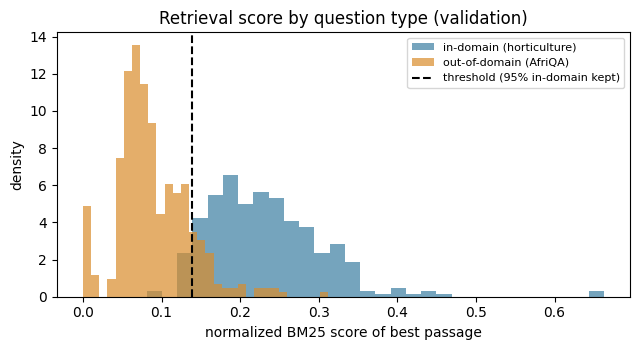

In [20]:
def top_scores(question_texts):
    raw, norm = [], []
    for text in question_texts:
        q_tokens = tok(text)
        s = bm25.scores(q_tokens)
        raw.append(float(s.max())); norm.append(bm25.normalized_top_score(q_tokens, float(s.max())))
    return np.array(raw), np.array(norm)

scores = {}
for name, qs in (("val", val), ("test", test)):
    scores[("in", name)] = top_scores([q["question"] for q in qs])
    scores[("ood", name)] = top_scores([q["question"] for q in ood[name]])

ood_results = {}
for kind, idx in (("raw_bm25_score", 0), ("normalized_score", 1)):
    inn_v, ood_v = scores[("in", "val")][idx], scores[("ood", "val")][idx]
    tau = float(np.quantile(inn_v, 0.05))                    # 95% of in-domain validation questions score >= tau
    entry = {"threshold_from_val": round(tau, 4)}
    for name in ("val", "test"):
        inn, oo = scores[("in", name)][idx], scores[("ood", name)][idx]
        y = np.r_[np.ones(len(inn)), np.zeros(len(oo))]; sc = np.r_[inn, oo]
        entry[name] = {"AUROC": round(float(roc_auc_score(y, sc)), 4),
                       "in_domain_answered": round(float((inn >= tau).mean()), 4),
                       "out_of_domain_refused": round(float((oo < tau).mean()), 4)}
    ood_results[kind] = entry
print(json.dumps(ood_results, indent=2))

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(scores[("in", "val")][1], bins=30, alpha=0.7, label="in-domain (horticulture)", color="#3b7ea1", density=True)
ax.hist(scores[("ood", "val")][1], bins=30, alpha=0.7, label="out-of-domain (AfriQA)", color="#d98c2b", density=True)
ax.axvline(ood_results["normalized_score"]["threshold_from_val"], color="k", ls="--", label="threshold (95% in-domain kept)")
ax.set_xlabel("normalized BM25 score of best passage"); ax.set_ylabel("density"); ax.set_title("Retrieval score by question type (validation)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "baseline_ood_score_hist.png", dpi=150); plt.show()

### 2.4 Baseline results table
All numbers below are read from the variables computed above and saved to `results/baseline/`.

In [21]:
best_retr = retr_df[retr_df["tokenizer"] == best_name].set_index("split")
summary_rows = []
for name in ("val", "test"):
    r = results[name]
    summary_rows.append({"split": name, "n": r["n_questions"], "retrieval recall@1": r["retrieval_recall@1"],
                         "recall@5": best_retr.loc[name, "recall@5"], "recall@10": best_retr.loc[name, "recall@10"],
                         "random window EM/F1 (oracle)": f'{r["random_window_oracle"]["EM"]} / {r["random_window_oracle"]["F1"]}',
                         "whole sentence EM/F1 (oracle)": f'{r["whole_best_sentence_oracle"]["EM"]} / {r["whole_best_sentence_oracle"]["F1"]}',
                         "window reader EM/F1 (oracle)": f'{r["oracle_passage"]["EM"]} / {r["oracle_passage"]["F1"]}',
                         "window reader EM/F1 (BM25 top-1)": f'{r["end_to_end_bm25_top1"]["EM"]} / {r["end_to_end_bm25_top1"]["F1"]}',
                         "OOD AUROC (normalized)": ood_results["normalized_score"][name]["AUROC"]})
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(BASE / "summary.csv", index=False)

save_json({"seed": SEED, "bm25": {"k1": 1.5, "b": 0.75, "tokenizer": best_name, "chosen_on": "validation recall@1"},
           "reader": {"type": "rule-based best-sentence + window", "W": BEST_W, "W_chosen_on": "train F1, oracle passage"},
           "results": results, "ood": ood_results, "retrieval_table_file": "retrieval_results.csv"}, BASE / "metrics.json")
summary_df.T

,0,1
split,val,test
n,330,335
retrieval recall@1,0.5576,0.4597
recall@5,0.8727,0.806
recall@10,0.9455,0.8925
random window EM/F1 (oracle),0.0 / 0.0474,0.0 / 0.071
whole sentence EM/F1 (oracle),0.0 / 0.1185,0.003 / 0.1179
window reader EM/F1 (oracle),0.0 / 0.1051,0.003 / 0.0933
window reader EM/F1 (BM25 top-1),0.0 / 0.0706,0.003 / 0.0681
OOD AUROC (normalized),0.9693,0.9629


### 2.5 Zero-shot pretrained baseline: `deepset/xlm-roberta-base-squad2`
**What it is:** XLM-RoBERTa-base (a Transformer encoder pretrained on text in about 100 languages, including Swahili) that was then fine-tuned on **English** SQuAD 2.0 by deepset (license CC BY 4.0, 277M parameters). **Zero-shot** means we use it as is: it has never seen our data or been trained on Swahili QA. Whatever it does here comes from transfer across languages.

**How an extractive QA model answers (all of it is written out below, not hidden in a `pipeline`):**
1. The tokenizer joins `[question] [passage]` into subword tokens. Passages longer than 384 tokens are cut into overlapping windows (stride 128).
2. The model outputs, for every token, a **start score** and an **end score** (two numbers per token).
3. The answer is the span (start token i, end token j, i <= j, at most 30 tokens) with the highest `start[i] + end[j]`, restricted to passage tokens. Token offsets map the span back to the original text.
4. SQuAD 2.0 models were trained to also say "no answer" by pointing at the first token (`<s>`). That **null score** `start[0] + end[0]` competes with the best span.

**Refusal signal:** `margin = best_span_score - null_score`. A high margin means the model is confident the answer is in the passage. The model's own rule refuses when `margin < 0`. We also test a tuned threshold chosen on validation (same protocol as the BM25 rule).

Nothing is trained or tuned here except that threshold. Fixed choices: max length 384, stride 128, max answer length 30 tokens (common defaults).

In [22]:
import torch
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

ZS_MODEL = "deepset/xlm-roberta-base-squad2"
MAX_LEN, STRIDE, MAX_ANS_TOKENS = 384, 128, 30
torch.manual_seed(SEED)
zs_tok = AutoTokenizer.from_pretrained(ZS_MODEL)
zs_model = AutoModelForQuestionAnswering.from_pretrained(ZS_MODEL).eval()
zs_revision = getattr(zs_model.config, "_commit_hash", None)
ZS_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"        # a GPU (e.g. Colab T4) makes the next cells minutes instead of an hour
zs_model.to(ZS_DEVICE)
print("model:", ZS_MODEL, "| revision:", zs_revision, "| parameters:", sum(p.numel() for p in zs_model.parameters()), "| device:", ZS_DEVICE)

config.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model: deepset/xlm-roberta-base-squad2 | revision: None | parameters: 277454594 | device: cuda


In [23]:
@torch.inference_mode()
def zs_predict(question, context):
    # Returns (answer_text, best_span_score, null_score) for one question and one passage.
    enc = zs_tok(question, context, truncation="only_second", max_length=MAX_LEN, stride=STRIDE,
                 return_overflowing_tokens=True, return_offsets_mapping=True, padding=True, return_tensors="pt")
    offsets = enc.pop("offset_mapping"); enc.pop("overflow_to_sample_mapping")
    out = zs_model(**{k: v.to(ZS_DEVICE) for k, v in enc.items()})
    all_start, all_end = out.start_logits.float().cpu(), out.end_logits.float().cpu()      # the loops below run on the CPU
    best_text, best_score, null_score = "", -1e9, 1e9
    for w in range(enc["input_ids"].shape[0]):                       # one row per window of the passage
        start, end = all_start[w], all_end[w]
        null_score = min(null_score, float(start[0] + end[0]))       # SQuAD2 rule: smallest null score over windows
        seq_ids = enc.sequence_ids(w)                                # 0 = question token, 1 = passage token, None = special
        for i in torch.topk(start, 20).indices.tolist():
            for j in torch.topk(end, 20).indices.tolist():
                if seq_ids[i] != 1 or seq_ids[j] != 1 or j < i or j - i + 1 > MAX_ANS_TOKENS:
                    continue
                score = float(start[i] + end[j])
                if score > best_score:
                    best_score = score
                    best_text = context[offsets[w][i][0]: offsets[w][j][1]]
    return best_text.strip(), best_score, null_score

# smoke test on one question (the model is slow on CPU, so check before the full run)
q0 = val[0]
print(q0["question"], "| gold:", q0["answer"], "| model:", zs_predict(q0["question"], ctx_of[q0["pid"]]))

Kisahani kina faida gani kwenye mmea wa tufaa? | gold: kukusanya maji | model: ('kuacha kisahani kwa ajili ya kukusanya maji ya mvua au unapomwagilia', 0.8097209334373474, 4.312633514404297)


In [24]:
ZS_CACHE = (Path("/content") if "google.colab" in sys.modules else BASE) / "zeroshot_cache.jsonl"   # one line per (kind, question id, passage); resumable; local disk on Colab (many tiny appends are slow on Drive)
cache = {}
if ZS_CACHE.exists():
    for line in ZS_CACHE.read_text(encoding="utf-8").splitlines():
        r = json.loads(line); cache[(r["kind"], r["id"], r["pid"])] = r

def zs_cached(kind, qid, question, pid):
    key = (kind, qid, pid)
    if key not in cache:
        text, best, null = zs_predict(question, ctx_of[pid])
        cache[key] = {"kind": kind, "id": qid, "pid": pid, "text": text, "best": best, "null": null}
        with open(ZS_CACHE, "a", encoding="utf-8") as f:
            f.write(json.dumps(cache[key], ensure_ascii=False) + "\n")
    return cache[key]

t0 = time.time()
zs = {}                                        # zs[(setting, split)] = list of records aligned with the questions
for name, qs in (("val", val), ("test", test)):
    # in-domain, correct passage (oracle) and in-domain, BM25 top-1 passage (end-to-end)
    zs[("oracle", name)] = [zs_cached("in", q["id"], q["question"], q["pid"]) for q in qs]
    top1 = [retrieve(q["question"])[0][0] for q in qs]
    zs[("e2e", name)] = [zs_cached("in", q["id"], q["question"], p) for q, p in zip(qs, top1)]
    # out-of-domain questions: the system still retrieves a passage, and the reader reads it
    ood_top1 = [retrieve(q["question"])[0][0] for q in ood[name]]
    zs[("ood", name)] = [zs_cached("ood", q["id"], q["question"], p) for q, p in zip(ood[name], ood_top1)]
    print(f"{name} done, {time.time() - t0:.0f}s elapsed")

val done, 22s elapsed
test done, 42s elapsed


In [25]:
def qa_scores(questions, records):
    em = float(np.mean([exact_match(r["text"], q["answer"]) for q, r in zip(questions, records)]))
    f1 = float(np.mean([f1_score(r["text"], q["answer"]) for q, r in zip(questions, records)]))
    return {"EM": round(em, 4), "F1": round(f1, 4)}

margin = lambda recs: np.array([r["best"] - r["null"] for r in recs])
zs_results = {"model": ZS_MODEL, "revision": zs_revision, "license": "CC BY 4.0", "settings": {"max_len": MAX_LEN, "stride": STRIDE, "max_answer_tokens": MAX_ANS_TOKENS}}
tau_zs = float(np.quantile(margin(zs[("e2e", "val")]), 0.05))      # 95% of in-domain validation questions have margin >= tau
for name, qs in (("val", val), ("test", test)):
    inn, oo = margin(zs[("e2e", name)]), margin(zs[("ood", name)])
    y = np.r_[np.ones(len(inn)), np.zeros(len(oo))]
    zs_results[name] = {
        "oracle_passage": qa_scores(qs, zs[("oracle", name)]),
        "end_to_end_bm25_top1": qa_scores(qs, zs[("e2e", name)]),
        "model_own_rule_margin<0": {"in_domain_answered": round(float((inn >= 0).mean()), 4), "out_of_domain_refused": round(float((oo < 0).mean()), 4)},
        "tuned_threshold": {"threshold_from_val": round(tau_zs, 4), "in_domain_answered": round(float((inn >= tau_zs).mean()), 4),
                            "out_of_domain_refused": round(float((oo < tau_zs).mean()), 4)},
        "AUROC_margin": round(float(roc_auc_score(y, np.r_[inn, oo])), 4)}
zs_results["compute_seconds_this_run"] = round(time.time() - t0)
save_json(zs_results, BASE / "zeroshot_metrics.json")
for name, qs in (("val", val), ("test", test)):
    write_jsonl([{"id": q["id"], "question": q["question"], "gold_answer": q["answer"], "gold_pid": q["pid"],
                  "pred_oracle": a["text"], "pred_end_to_end": b["text"], "retrieved_pid": b["pid"],
                  "f1_oracle": round(f1_score(a["text"], q["answer"]), 3), "f1_end_to_end": round(f1_score(b["text"], q["answer"]), 3),
                  "margin_end_to_end": round(b["best"] - b["null"], 3)}
                 for q, a, b in zip(qs, zs[("oracle", name)], zs[("e2e", name)])], BASE / f"zeroshot_predictions_{name}.jsonl")
print(json.dumps(zs_results, indent=2))

{
  "model": "deepset/xlm-roberta-base-squad2",
  "revision": null,
  "license": "CC BY 4.0",
  "settings": {
    "max_len": 384,
    "stride": 128,
    "max_answer_tokens": 30
  },
  "val": {
    "oracle_passage": {
      "EM": 0.3091,
      "F1": 0.446
    },
    "end_to_end_bm25_top1": {
      "EM": 0.1667,
      "F1": 0.2722
    },
    "model_own_rule_margin<0": {
      "in_domain_answered": 0.3788,
      "out_of_domain_refused": 0.9951
    },
    "tuned_threshold": {
      "threshold_from_val": -9.6238,
      "in_domain_answered": 0.9485,
      "out_of_domain_refused": 0.449
    },
    "AUROC_margin": 0.8927
  },
  "test": {
    "oracle_passage": {
      "EM": 0.3433,
      "F1": 0.492
    },
    "end_to_end_bm25_top1": {
      "EM": 0.1701,
      "F1": 0.263
    },
    "model_own_rule_margin<0": {
      "in_domain_answered": 0.3224,
      "out_of_domain_refused": 0.9934
    },
    "tuned_threshold": {
      "threshold_from_val": -9.6238,
      "in_domain_answered": 0.9642,
      

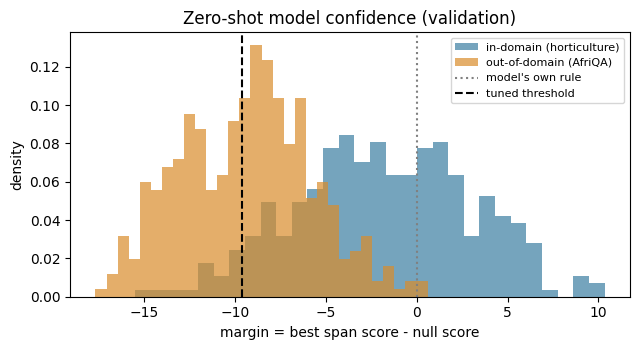

,system,split,oracle EM/F1,end-to-end EM/F1,OOD AUROC
0,rule-based reader + BM25,val,0.0 / 0.1051,0.0 / 0.0706,0.9693
1,rule-based reader + BM25,test,0.003 / 0.0933,0.003 / 0.0681,0.9629
2,zero-shot XLM-R-base-SQuAD2 + BM25,val,0.3091 / 0.446,0.1667 / 0.2722,0.8927
3,zero-shot XLM-R-base-SQuAD2 + BM25,test,0.3433 / 0.492,0.1701 / 0.263,0.9061


In [26]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(margin(zs[("e2e", "val")]), bins=30, alpha=0.7, label="in-domain (horticulture)", color="#3b7ea1", density=True)
ax.hist(margin(zs[("ood", "val")]), bins=30, alpha=0.7, label="out-of-domain (AfriQA)", color="#d98c2b", density=True)
ax.axvline(0, color="grey", ls=":", label="model's own rule"); ax.axvline(tau_zs, color="k", ls="--", label="tuned threshold")
ax.set_xlabel("margin = best span score - null score"); ax.set_ylabel("density"); ax.set_title("Zero-shot model confidence (validation)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "zeroshot_margin_hist.png", dpi=150); plt.show()

# side-by-side with the BM25 + rule-based baseline (all numbers read from saved results)
compare = pd.DataFrame([
    {"system": "rule-based reader + BM25", "split": n, "oracle EM/F1": f'{results[n]["oracle_passage"]["EM"]} / {results[n]["oracle_passage"]["F1"]}',
     "end-to-end EM/F1": f'{results[n]["end_to_end_bm25_top1"]["EM"]} / {results[n]["end_to_end_bm25_top1"]["F1"]}',
     "OOD AUROC": ood_results["normalized_score"][n]["AUROC"]} for n in ("val", "test")] + [
    {"system": "zero-shot XLM-R-base-SQuAD2 + BM25", "split": n, "oracle EM/F1": f'{zs_results[n]["oracle_passage"]["EM"]} / {zs_results[n]["oracle_passage"]["F1"]}',
     "end-to-end EM/F1": f'{zs_results[n]["end_to_end_bm25_top1"]["EM"]} / {zs_results[n]["end_to_end_bm25_top1"]["F1"]}',
     "OOD AUROC": zs_results[n]["AUROC_margin"]} for n in ("val", "test")])
compare.to_csv(BASE / "baseline_comparison.csv", index=False)
compare

### Phase 3 outputs (so far)
- `results/baseline/`: `metrics.json`, `summary.csv`, `retrieval_results.csv`, `predictions_val.jsonl`, `predictions_test.jsonl`
- `results/figures/`: `baseline_retrieval_recall.png`, `baseline_ood_score_hist.png`

- `zeroshot_metrics.json`, `zeroshot_predictions_{val,test}.jsonl`, `zeroshot_cache.jsonl`, `baseline_comparison.csv`; figure `zeroshot_margin_hist.png`

## Part 3. Proposed approach and experiments (Phase 4)

Part 2 showed three things: (1) a zero-shot multilingual reader is far better than rules (oracle test F1 0.49 vs 0.09), (2) retrieval is the bottleneck (end-to-end F1 is about half of oracle), and (3) the model's own refusal signal is poor. Part 3 tests what can improve each, one change at a time, all selected on **validation** only.

| ID | Experiment | Question it answers | Where it runs |
|---|---|---|---|
| E1 | Read the top-k BM25 passages (k = 1, 3, 5) and keep the best answer | Does reading more passages repair retrieval misses? | this notebook (CPU, about 25 min) |
| E2 | Combine BM25 score and model margin into one refusal signal | Is the combination better than either signal alone? | this notebook (seconds) |
| E3 | **Head-only fine-tuning:** freeze the encoder, train only the final start/end layer on our training split | How much does adapting just the output layer to Swahili horticulture help? | this notebook (CPU, about 20 min) |
| E4 | **Full fine-tuning** of three encoders (XLM-R-base-SQuAD2, AfroXLMR-base, XLM-R-base), then seeds and learning rates for the best | Does training the whole model on our data beat zero-shot, and which starting point is best? | **Google Colab T4** (cells below run only when a GPU is present) |
| E5 | **Three models built and trained from scratch**: BiGRU with attention, BiLSTM with attention, and a Transformer encoder (word-level, no pretrained files) | What do the class models achieve on this data without pretraining, and which is best? | Colab T4 (slow on CPU) |
| E6 | The **deployed model** is the best of the three E5 models by validation F1; fit its refusal rule from BM25 score and model confidence | How good is the pipeline that the web app actually runs? | same run as E5 |

**Why E4 is not run on this laptop:** I measured fine-tuning speed on this CPU (8 cores): about 3.3 s per training example at 384 tokens, i.e. roughly 5 hours for 3 epochs of one configuration. That exceeds the one-hour limit, so E4 is written here and run on the free T4.

**Smoke mode:** setting the environment variable `QA_SMOKE=1` runs Part 3 on tiny subsets and writes to `results/_smoke/`. It exists only to test that the code runs; it never touches real results.

In [27]:
import os
SMOKE = os.environ.get("QA_SMOKE") == "1"
SKIP_PRETRAINED_EXP = os.environ.get("QA_SKIP_PRETRAINED_EXP") == "1"      # skip E1 and E3 (slow on a CPU); the Colab run does everything
import torch.nn as nn
EXP = ROOT / "results" / ("_smoke" if SMOKE else "experiments"); EXP.mkdir(parents=True, exist_ok=True)
HAS_GPU = torch.cuda.is_available(); DEVICE = "cuda" if HAS_GPU else "cpu"
torch.set_num_threads(os.cpu_count() or 4)

if SMOKE:
    train_p3, val_p3, test_p3 = train[:40], val[:30], test[:30]
    ood_p3 = {k: v[:30] for k, v in ood.items()}
else:
    train_p3, val_p3, test_p3, ood_p3 = train, val, test, ood
print("smoke mode:", SMOKE, "| device:", DEVICE, "| train/val/test questions:", len(train_p3), len(val_p3), len(test_p3), "| results dir:", EXP)

smoke mode: False | device: cuda | train/val/test questions: 1560 330 335 | results dir: /content/drive/MyDrive/ML_technique_1/Summative/results/experiments


### 3.1 Shared building blocks
Everything E1 to E4 needs, written out once and checked.

- **`decode_span`:** from one window's start/end scores, the best answer span (same rule as Part 2).
- **`reader_predict`:** question + passage in, `(answer, best_span_score, null_score)` out, for *any* model. (Part 2's `zs_predict` is the same logic fixed to the zero-shot model.)
- **`make_features`:** turns a question and its passage into training examples. The passage is cut into overlapping windows, and for each window we compute the **token position of the gold answer's start and end** from its character positions. If the answer is not inside a window, both labels point at token 0 (`<s>`), which is how SQuAD 2.0 models learn "no answer in this window". We check the labels by decoding them back to text.

In [28]:
def decode_span(start_logits, end_logits, offsets, seq_ids, context, max_ans=MAX_ANS_TOKENS, topn=20):
    """Best (text, score) span inside the passage tokens of ONE window. Passage tokens have seq_id == 1."""
    best_text, best_score = "", -1e9
    for i in np.argsort(-start_logits)[:topn]:
        for j in np.argsort(-end_logits)[:topn]:
            if seq_ids[i] != 1 or seq_ids[j] != 1 or j < i or j - i + 1 > max_ans:
                continue
            score = float(start_logits[i] + end_logits[j])
            if score > best_score:
                best_score, best_text = score, context[offsets[i][0]: offsets[j][1]]
    return best_text, best_score

@torch.inference_mode()
def reader_predict(model, tokz, question, context, device="cpu"):
    enc = tokz(question, context, truncation="only_second", max_length=MAX_LEN, stride=STRIDE,
               return_overflowing_tokens=True, return_offsets_mapping=True, padding=True, return_tensors="pt")
    offsets = enc.pop("offset_mapping"); enc.pop("overflow_to_sample_mapping")
    out = model(**{k: v.to(device) for k, v in enc.items()})
    S, E = out.start_logits.float().cpu().numpy(), out.end_logits.float().cpu().numpy()
    best_text, best_score, null = "", -1e9, 1e9
    for w in range(S.shape[0]):
        null = min(null, float(S[w, 0] + E[w, 0]))
        text, score = decode_span(S[w], E[w], offsets[w].tolist(), enc.sequence_ids(w), context)
        if score > best_score:
            best_text, best_score = text, score
    return best_text.strip(), best_score, null

def make_features(rows, tokz, max_len=MAX_LEN, stride=STRIDE):
    """One feature per window. Returns a dict of lists plus per-feature metadata for decoding and checking."""
    enc = tokz([r["question"] for r in rows], [r["context"] for r in rows], truncation="only_second", max_length=max_len,
               stride=stride, return_overflowing_tokens=True, return_offsets_mapping=True, padding="max_length")
    F = {"input_ids": [], "attention_mask": [], "start": [], "end": [], "row": [], "offsets": [], "seq_ids": []}
    for i in range(len(enc["input_ids"])):
        r = rows[enc["overflow_to_sample_mapping"][i]]
        seq, offs = enc.sequence_ids(i), enc["offset_mapping"][i]
        s_char, e_char = r["answer_start"], r["answer_start"] + len(r["answer"])
        c0 = seq.index(1); c1 = len(seq) - 1 - seq[::-1].index(1)           # first and last passage token of this window
        if offs[c0][0] > s_char or offs[c1][1] < e_char:                    # answer not fully inside this window
            start = end = 0
        else:
            a = c0
            while a <= c1 and offs[a][0] <= s_char: a += 1
            b = c1
            while b >= c0 and offs[b][1] >= e_char: b -= 1
            start, end = a - 1, b + 1
        F["input_ids"].append(enc["input_ids"][i]); F["attention_mask"].append(enc["attention_mask"][i])
        F["start"].append(start); F["end"].append(end); F["row"].append(enc["overflow_to_sample_mapping"][i])
        F["offsets"].append(offs); F["seq_ids"].append(seq)
    return F

# --- check the labels: decode the labelled span back to text and compare with the gold answer
_tz = AutoTokenizer.from_pretrained(ZS_MODEL)
chk = make_features(train[:200], _tz)
has_ans = [i for i, s in enumerate(chk["start"]) if s > 0]
ok = sum(normalize_answer(train[chk["row"][i]]["context"][chk["offsets"][i][chk["start"][i]][0]: chk["offsets"][i][chk["end"][i]][1]]) == normalize_answer(train[chk["row"][i]]["answer"]) for i in has_ans)
print(f"features from 200 questions: {len(chk['input_ids'])} windows, {len(has_ans)} contain the answer; decoded label equals gold answer in {ok}/{len(has_ans)}")
assert ok / len(has_ans) > 0.95, "answer-position labels look wrong"

features from 200 questions: 228 windows, 210 contain the answer; decoded label equals gold answer in 209/210


### 3.2 E1: read the top-k retrieved passages
BM25 puts the right passage first for only about half of questions but in the top 10 for about 90%. So read the top *k* passages with the zero-shot reader and keep one answer. Two ways to choose among the k candidate answers: the highest **span score** (how sure the model is of that span) or the highest **margin** (span score minus null score; also accounts for the model thinking the passage has no answer). `k = 1` reproduces Part 2's end-to-end result, which is a built-in check. The reader's outputs are cached on disk, so passages already read in Part 2 cost nothing.

In [29]:
if not SKIP_PRETRAINED_EXP:
    def topk_pids(question, k):
        s = bm25.scores(tok(question)); order = np.argsort(-s, kind="stable")[:k]
        return [pid_list[i] for i in order]

    def read_topk(questions, k, rule):
        preds = []
        for q in questions:
            cands = [zs_cached("in", q["id"], q["question"], p) for p in topk_pids(q["question"], k)]
            key = (lambda r: r["best"]) if rule == "span score" else (lambda r: r["best"] - r["null"])
            preds.append(max(cands, key=key))
        return preds

    t0 = time.time(); e1_rows = []
    for name, qs in (("val", val_p3), ("test", test_p3)):
        for k in (1, 3, 5):
            for rule in (("span score", "margin") if k > 1 else ("span score",)):
                recs = read_topk(qs, k, rule)
                sc = qa_scores(qs, recs)
                e1_rows.append({"split": name, "k": k, "choose_by": rule, "EM": sc["EM"], "F1": sc["F1"],
                                "chosen_passage_is_correct": round(float(np.mean([r["pid"] == q["pid"] for r, q in zip(recs, qs)])), 4)})
            print(f"{name} k={k} done, {time.time() - t0:.0f}s")
    e1_df = pd.DataFrame(e1_rows); e1_df.to_csv(EXP / "e1_topk_reading.csv", index=False)
    e1_df

val k=1 done, 0s
val k=3 done, 20s
val k=5 done, 38s
test k=1 done, 39s
test k=3 done, 56s
test k=5 done, 75s


In [30]:
if not SKIP_PRETRAINED_EXP:
    # Part 2 check: k = 1 must reproduce the earlier end-to-end numbers (only meaningful on the full data)
    if not SMOKE:
        k1 = e1_df[(e1_df["k"] == 1)].set_index("split")
        for name in ("val", "test"):
            assert abs(k1.loc[name, "F1"] - zs_results[name]["end_to_end_bm25_top1"]["F1"]) < 1e-3, "k=1 does not match Part 2"
        print("k=1 reproduces Part 2 end-to-end results: OK")
    # choose (k, rule) on VALIDATION F1
    v = e1_df[e1_df["split"] == "val"].sort_values(["F1", "k"], ascending=[False, True]).iloc[0]
    E1_BEST = {"k": int(v["k"]), "choose_by": v["choose_by"]}
    print("E1 selected on validation F1:", E1_BEST)

k=1 reproduces Part 2 end-to-end results: OK
E1 selected on validation F1: {'k': 5, 'choose_by': 'margin'}


### 3.3 E2: a better refusal signal
Part 2 found two signals for "should we answer?": the normalised **BM25 score** of the best passage (AUROC 0.96) and the zero-shot **margin** (AUROC 0.91). They look at different things (word overlap with the collection versus the reader's confidence in a span). We fit a small **logistic regression** on the two signals using **validation** questions only (in-domain = 1, out-of-domain = 0, features standardised), then apply it unchanged to test. The threshold keeps 95% of in-domain validation questions answered, as before.

In [31]:
from sklearn.linear_model import LogisticRegression

def signal_matrix(name):
    """rows = in-domain questions then out-of-domain questions; columns = [normalized BM25 score, zero-shot margin]"""
    n_in, n_out = len(zs[("e2e", name)]), len(zs[("ood", name)])
    bm_in, bm_out = scores[("in", name)][1][:n_in], scores[("ood", name)][1][:n_out]
    X = np.c_[np.r_[bm_in, bm_out], np.r_[margin(zs[("e2e", name)]), margin(zs[("ood", name)])]]
    y = np.r_[np.ones(n_in), np.zeros(n_out)]
    return X, y, n_in

# in smoke mode zs[...] covers the full Part 2 sets; subset to the smoke questions so shapes match
Xv, yv, nv = signal_matrix("val"); Xt, yt, nt = signal_matrix("test")
mu, sd = Xv.mean(0), Xv.std(0)
clf = LogisticRegression(class_weight="balanced", max_iter=1000).fit((Xv - mu) / sd, yv)
sig = {"BM25 score only": lambda X: X[:, 0], "model margin only": lambda X: X[:, 1],
       "combined (logistic regression)": lambda X: clf.decision_function((X - mu) / sd)}
e2_rows, TAU = [], {}
for sname, f in sig.items():
    tau = float(np.quantile(f(Xv)[:nv], 0.05)); TAU[sname] = tau          # keep 95% of in-domain validation questions
    row = {"signal": sname}
    for split_name, X, y, n_in in (("val", Xv, yv, nv), ("test", Xt, yt, nt)):
        s = f(X)
        row[f"AUROC {split_name}"] = round(float(roc_auc_score(y, s)), 4)
        row[f"in-domain answered {split_name}"] = round(float((s[:n_in] >= tau).mean()), 4)
        row[f"out-of-domain refused {split_name}"] = round(float((s[n_in:] < tau).mean()), 4)
    e2_rows.append(row)
e2_df = pd.DataFrame(e2_rows); e2_df.to_csv(EXP / "e2_refusal_signals.csv", index=False)
print("logistic regression weights on standardised [BM25 score, margin]:", clf.coef_.round(3).tolist(), "intercept", clf.intercept_.round(3).tolist())
e2_df.T

logistic regression weights on standardised [BM25 score, margin]: [[3.521, 1.461]] intercept [-0.013]


,0,1,2
signal,BM25 score only,model margin only,combined (logistic regression)
AUROC val,0.9693,0.8927,0.9784
in-domain answered val,0.9485,0.9485,0.9485
out-of-domain refused val,0.8811,0.449,0.8981
AUROC test,0.9629,0.9061,0.9743
in-domain answered test,0.9045,0.9642,0.9284
out-of-domain refused test,0.887,0.485,0.9003


selected on validation AUROC: combined (logistic regression) | threshold: -0.479


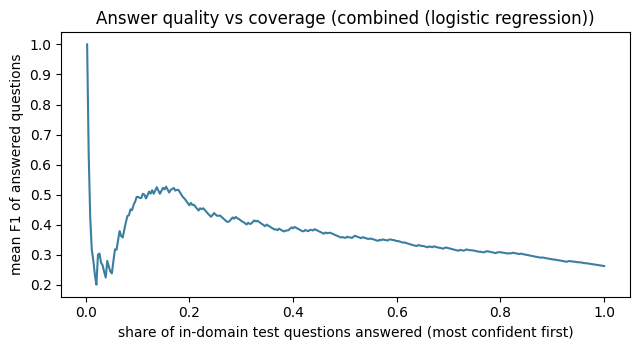

In [32]:
# Which signal to deploy? Pick by validation AUROC. Save everything the web app needs to reproduce it.
E2_BEST = max(sig, key=lambda s: e2_df.set_index("signal").loc[s, "AUROC val"])
refusal_config = {"signal": E2_BEST, "threshold": TAU[E2_BEST], "feature_mean": mu.tolist(), "feature_std": sd.tolist(),
                  "lr_coef": clf.coef_[0].tolist(), "lr_intercept": float(clf.intercept_[0]),
                  "features": ["normalized_bm25_top_score", "zero_shot_margin"], "target_in_domain_answered_on_val": 0.95}
save_json(refusal_config, EXP / "refusal_config.json")
print("selected on validation AUROC:", E2_BEST, "| threshold:", round(TAU[E2_BEST], 4))

# accuracy-vs-coverage: if we answer only the most confident in-domain questions, how good are the answers?
f_best = sig[E2_BEST]
conf = f_best(Xt)[:nt]; recs = zs[("e2e", "test")]
f1s = np.array([f1_score(r["text"], q["answer"]) for q, r in zip(test, recs)])   # always the full test set: recs and conf cover it
order = np.argsort(-conf); cov = np.arange(1, len(order) + 1) / len(order)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(cov, np.cumsum(f1s[order]) / np.arange(1, len(order) + 1), color="#3b7ea1")
ax.set_xlabel("share of in-domain test questions answered (most confident first)"); ax.set_ylabel("mean F1 of answered questions")
ax.set_title(f"Answer quality vs coverage ({E2_BEST})"); plt.tight_layout(); plt.savefig(FIG / (("_smoke_" if SMOKE else "") + "e2_coverage_curve.png"), dpi=150); plt.show()

### 3.4 E3: head-only fine-tuning
The model has two parts: the **encoder** (12 Transformer layers that turn tokens into 768-number vectors) and a **head** (one linear layer that turns each vector into a start score and an end score). Here we **freeze the encoder** and train only the head on our training questions (oracle passage), starting from the head that deepset trained on English SQuAD 2.0.

Why this is useful even though it is limited: it is cheap enough to run on CPU (the encoder is run once and its outputs are cached, then the head trains in seconds), and it tells us how much of the gap comes from the output layer alone. Everything the encoder knows about Swahili stays fixed.

Grid: learning rate in {1e-3, 3e-4}, 3 epochs, batch 16, 3 seeds each. **Epoch 0** (the untouched head) must reproduce the zero-shot oracle score, a built-in check. Choice by mean validation F1.

In [33]:
if not SKIP_PRETRAINED_EXP:
    t0 = time.time()
    ft_tok = AutoTokenizer.from_pretrained(ZS_MODEL)
    feats = {"train": make_features(train_p3, ft_tok), "val": make_features(val_p3, ft_tok), "test": make_features(test_p3, ft_tok)}

    @torch.inference_mode()
    def encode_all(F, batch=16):
        """Run the frozen encoder once; keep last-layer vectors in half precision to save memory."""
        out = []
        for i in range(0, len(F["input_ids"]), batch):
            ids = torch.tensor(F["input_ids"][i:i + batch]).to(ZS_DEVICE); am = torch.tensor(F["attention_mask"][i:i + batch]).to(ZS_DEVICE)
            out.append(zs_model.base_model(input_ids=ids, attention_mask=am).last_hidden_state.half().cpu())
        return torch.cat(out)

    H = {}
    for s in ("train", "val", "test"):
        H[s] = encode_all(feats[s]); print(f"encoded {s}: {tuple(H[s].shape)}  {time.time() - t0:.0f}s")

encoded train: (1797, 384, 768)  53s
encoded val: (397, 384, 768)  63s
encoded test: (400, 384, 768)  73s


In [34]:
if not SKIP_PRETRAINED_EXP:
    def head_eval(head, split, questions):
        """Oracle-passage EM/F1 of a head on cached encoder outputs. One answer per question (best window)."""
        F = feats[split]
        with torch.inference_mode():
            lg = head(H[split].float()); S, E = lg[..., 0].numpy(), lg[..., 1].numpy()
        best = {}
        for i in range(len(F["input_ids"])):
            r = F["row"][i]
            text, sc = decode_span(S[i], E[i], F["offsets"][i], F["seq_ids"][i], questions[r]["context"])
            if r not in best or sc > best[r][1]:
                best[r] = (text.strip(), sc)
        preds = [best[r][0] for r in range(len(questions))]
        return {"EM": round(float(np.mean([exact_match(p, q["answer"]) for p, q in zip(preds, questions)])), 4),
                "F1": round(float(np.mean([f1_score(p, q["answer"]) for p, q in zip(preds, questions)])), 4)}

    def train_head(lr, epochs, seed, batch=16):
        torch.manual_seed(seed); g = torch.Generator().manual_seed(seed)
        head = nn.Linear(768, 2); head.load_state_dict(zs_model.qa_outputs.state_dict())     # start from the SQuAD2 head
        opt = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=0.0)
        F = feats["train"]; n = len(F["input_ids"])
        ys, ye, am = torch.tensor(F["start"]), torch.tensor(F["end"]), torch.tensor(F["attention_mask"])
        curve = [{"epoch": 0, "train_loss": None, **{f"val_{k}": v for k, v in head_eval(head, "val", val_p3).items()}}]
        for ep in range(1, epochs + 1):
            perm = torch.randperm(n, generator=g); total = 0.0
            for i in range(0, n, batch):
                idx = perm[i:i + batch]
                lg = head(H["train"][idx].float()).masked_fill(am[idx].unsqueeze(-1) == 0, -1e4)     # ignore padding positions
                loss = (nn.functional.cross_entropy(lg[..., 0], ys[idx]) + nn.functional.cross_entropy(lg[..., 1], ye[idx])) / 2
                opt.zero_grad(); loss.backward(); opt.step(); total += float(loss) * len(idx)
            curve.append({"epoch": ep, "train_loss": round(total / n, 4), **{f"val_{k}": v for k, v in head_eval(head, "val", val_p3).items()}})
        return head, curve

    e3_runs = []
    for lr in (1e-3, 3e-4):
        for seed in (42, 43, 44):
            head, curve = train_head(lr, 3, seed)
            e3_runs.append({"lr": lr, "seed": seed, "curve": curve, "head": head})
            print(f"lr={lr} seed={seed}: val F1 per epoch", [c["val_F1"] for c in curve], f"{time.time() - t0:.0f}s")

/tmp/ipykernel_812/948813644.py:30: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  opt.zero_grad(); loss.backward(); opt.step(); total += float(loss) * len(idx)


lr=0.001 seed=42: val F1 per epoch [0.446, 0.4693, 0.4989, 0.4974] 83s
lr=0.001 seed=43: val F1 per epoch [0.446, 0.473, 0.498, 0.4993] 91s
lr=0.001 seed=44: val F1 per epoch [0.446, 0.4751, 0.4951, 0.4988] 101s
lr=0.0003 seed=42: val F1 per epoch [0.446, 0.454, 0.4612, 0.4652] 108s
lr=0.0003 seed=43: val F1 per epoch [0.446, 0.4521, 0.4583, 0.463] 118s
lr=0.0003 seed=44: val F1 per epoch [0.446, 0.4534, 0.4649, 0.4731] 124s


epoch-0 val F1: 0.446 | Part 2 zero-shot oracle val F1: 0.446
{
 "zero_shot_val_F1": 0.446,
 "grid": [
  {
   "lr": 0.001,
   "val_F1_mean": 0.4985,
   "val_F1_std": 0.0008
  },
  {
   "lr": 0.0003,
   "val_F1_mean": 0.4671,
   "val_F1_std": 0.0043
  }
 ],
 "selected_lr": 0.001,
 "test_EM_mean": 0.399,
 "test_F1_mean": 0.5333,
 "test_F1_std": 0.0007,
 "seconds": 126
}


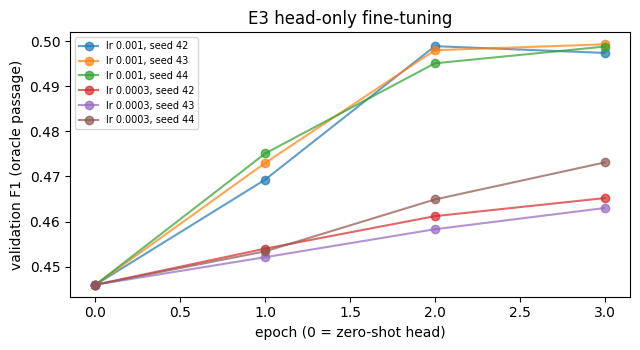

In [35]:
if not SKIP_PRETRAINED_EXP:
    # sanity check: epoch 0 (untouched SQuAD2 head) should match the zero-shot oracle score from Part 2
    if not SMOKE:
        e0 = e3_runs[0]["curve"][0]
        print("epoch-0 val F1:", e0["val_F1"], "| Part 2 zero-shot oracle val F1:", zs_results["val"]["oracle_passage"]["F1"])
        assert abs(e0["val_F1"] - zs_results["val"]["oracle_passage"]["F1"]) < 0.02, "head-only epoch 0 does not reproduce zero-shot (tolerance allows float16 rounding of cached encoder outputs)"

    cfg_rows = []
    for lr in (1e-3, 3e-4):
        rs = [r for r in e3_runs if r["lr"] == lr]
        f1_final = [r["curve"][-1]["val_F1"] for r in rs]
        cfg_rows.append({"lr": lr, "val_F1_mean": round(float(np.mean(f1_final)), 4), "val_F1_std": round(float(np.std(f1_final)), 4), "runs": rs})
    best_cfg = max(cfg_rows, key=lambda c: c["val_F1_mean"])
    test_scores = [head_eval(r["head"], "test", test_p3) for r in best_cfg["runs"]]
    e3_summary = {"zero_shot_val_F1": e3_runs[0]["curve"][0]["val_F1"], "grid": [{k: v for k, v in c.items() if k != "runs"} for c in cfg_rows],
                  "selected_lr": best_cfg["lr"], "test_EM_mean": round(float(np.mean([t["EM"] for t in test_scores])), 4),
                  "test_F1_mean": round(float(np.mean([t["F1"] for t in test_scores])), 4), "test_F1_std": round(float(np.std([t["F1"] for t in test_scores])), 4),
                  "curves": {f"lr{r['lr']}_seed{r['seed']}": r["curve"] for r in e3_runs}, "seconds": round(time.time() - t0)}
    save_json(e3_summary, EXP / "e3_head_only.json")
    print(json.dumps({k: v for k, v in e3_summary.items() if k != "curves"}, indent=1))

    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    for r in e3_runs:
        ax.plot([c["epoch"] for c in r["curve"]], [c["val_F1"] for c in r["curve"]], marker="o", alpha=0.7, label=f"lr {r['lr']:g}, seed {r['seed']}")
    ax.set_xlabel("epoch (0 = zero-shot head)"); ax.set_ylabel("validation F1 (oracle passage)"); ax.set_title("E3 head-only fine-tuning"); ax.legend(fontsize=7)
    plt.tight_layout(); plt.savefig(FIG / (("_smoke_" if SMOKE else "") + "e3_head_only_curves.png"), dpi=150); plt.show()

### 3.5 E4: full fine-tuning (Google Colab T4)
All 12 encoder layers and the head are trained on our training split (oracle passage as context), with the same decoding and metrics as everything above.

**Starting points compared**
1. `deepset/xlm-roberta-base-squad2`: XLM-R already trained for English extractive QA (the zero-shot model, now adapted to Swahili).
2. `Davlan/afro-xlmr-base`: XLM-R further pretrained on African languages (Alabi et al., 2022), but never trained for QA, so its head starts untrained. Licence MIT.
3. `FacebookAI/xlm-roberta-base`: the plain multilingual encoder, a control for (2). Licence MIT.

**Training recipe (same for all):** AdamW, linear warm-up over 10% of steps then linear decay, batch 16, 4 epochs, 384-token windows with stride 128, mixed precision on GPU, seeds fixed. Validation oracle EM/F1 is logged after every epoch (training curves). After training each run is scored on validation and test, oracle and end-to-end (BM25 top-1), and also saves the margins needed to analyse refusal.

**Protocol:** first, one run per starting point at its default learning rate (seed 42). Then the best on validation F1 gets two more seeds and two more learning rates. Test numbers are only read for reporting.

**Expected cost (an estimate, not measured):** a few minutes per run on a T4, so the whole grid should be well under one hour. If a run takes much longer, stop and check the GPU is enabled (Runtime > Change runtime type > T4).

**On Colab:** run the notebook top to bottom (Part 1 and 2 first; they are fast). Part 3's E1 to E3 also run there. Then download `results/experiments/` and commit it, so the later parts read the real numbers. Optionally upload the best checkpoint to the Hugging Face Hub (instructions in the last cell of this section).

In [36]:
import transformers
from transformers import get_linear_schedule_with_warmup

def run_finetune(model_id, lr, epochs, seed, tag, batch_size=16, save_dir=None):
    t_start = time.time()
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if HAS_GPU: torch.cuda.manual_seed_all(seed)
    tz = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForQuestionAnswering.from_pretrained(model_id).to(DEVICE)
    F = make_features(train_p3, tz)
    ids, am = torch.tensor(F["input_ids"]), torch.tensor(F["attention_mask"])
    ys, ye = torch.tensor(F["start"]), torch.tensor(F["end"])
    n = len(ids); steps = epochs * math.ceil(n / batch_size)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
    scaler = torch.amp.GradScaler("cuda", enabled=HAS_GPU)
    g = torch.Generator().manual_seed(seed)
    curve = []

    def val_scores():
        model.eval()
        recs = [reader_predict(model, tz, q["question"], q["context"], DEVICE) for q in val_p3]
        model.train()
        return qa_scores(val_p3, [{"text": r[0]} for r in recs])

    model.train()
    for ep in range(1, epochs + 1):
        perm = torch.randperm(n, generator=g); total = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=HAS_GPU):
                out = model(input_ids=ids[idx].to(DEVICE), attention_mask=am[idx].to(DEVICE),
                            start_positions=ys[idx].to(DEVICE), end_positions=ye[idx].to(DEVICE))
            opt.zero_grad(); scaler.scale(out.loss).backward(); scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sched.step(); total += float(out.loss) * len(idx)
        vs = val_scores()
        curve.append({"epoch": ep, "train_loss": round(total / n, 4), "val_EM": vs["EM"], "val_F1": vs["F1"]})
        print(f"[{tag}] epoch {ep}: train loss {curve[-1]['train_loss']}, val EM/F1 {vs['EM']}/{vs['F1']}  ({time.time() - t_start:.0f}s)")

    # final scoring: oracle passage, end-to-end (BM25 top-1) and out-of-domain margins, for validation and test
    model.eval(); result = {"tag": tag, "model_id": model_id, "lr": lr, "epochs": epochs, "seed": seed, "batch_size": batch_size,
                            "max_len": MAX_LEN, "stride": STRIDE, "train_questions": len(train_p3), "train_windows": n, "device": DEVICE,
                            "gpu": torch.cuda.get_device_name(0) if HAS_GPU else None, "torch": torch.__version__,
                            "transformers": transformers.__version__, "curve": curve}
    for name, qs in (("val", val_p3), ("test", test_p3)):
        top1 = [retrieve(q["question"])[0][0] for q in qs]
        o = [reader_predict(model, tz, q["question"], ctx_of[q["pid"]], DEVICE) for q in qs]
        e = [reader_predict(model, tz, q["question"], ctx_of[p], DEVICE) for q, p in zip(qs, top1)]
        ood_top1 = [retrieve(q["question"])[0][0] for q in ood_p3[name]]
        oo = [reader_predict(model, tz, q["question"], ctx_of[p], DEVICE) for q, p in zip(ood_p3[name], ood_top1)]
        result[name] = {"oracle_passage": qa_scores(qs, [{"text": r[0]} for r in o]),
                        "end_to_end_bm25_top1": qa_scores(qs, [{"text": r[0]} for r in e]),
                        "margins_in_domain_e2e": [round(r[1] - r[2], 4) for r in e], "margins_out_of_domain": [round(r[1] - r[2], 4) for r in oo]}
        write_jsonl([{"id": q["id"], "question": q["question"], "gold_answer": q["answer"], "gold_pid": q["pid"], "retrieved_pid": p,
                      "pred_oracle": a[0], "pred_end_to_end": b[0], "f1_oracle": round(f1_score(a[0], q["answer"]), 3),
                      "f1_end_to_end": round(f1_score(b[0], q["answer"]), 3), "margin_end_to_end": round(b[1] - b[2], 3)}
                     for q, p, a, b in zip(qs, top1, o, e)], EXP / f"ft_preds_{name}_{tag}.jsonl")
    result["seconds"] = round(time.time() - t_start)
    save_json(result, EXP / f"ft_{tag}.json")
    if save_dir:
        model.save_pretrained(save_dir); tz.save_pretrained(save_dir)
    del model
    if HAS_GPU: torch.cuda.empty_cache()
    return result
print("run_finetune defined")

run_finetune defined


In [37]:
FT_START = [("deepset/xlm-roberta-base-squad2", 2e-5, "xlmr_squad2"), ("Davlan/afro-xlmr-base", 3e-5, "afroxlmr"), ("FacebookAI/xlm-roberta-base", 3e-5, "xlmr_base")]
FT_EPOCHS = 4
RUN_STAGE_2 = True     # set to False to stop after the first three runs (saves roughly 35 to 50 minutes on a T4)

def run_full_grid():
    done = {}
    # stage 1: one run per starting point
    for model_id, lr, name in FT_START:
        tag = f"{name}_lr{lr:g}_s42"
        done[tag] = json.loads((EXP / f"ft_{tag}.json").read_text()) if (EXP / f"ft_{tag}.json").exists() else run_finetune(model_id, lr, FT_EPOCHS, 42, tag)
    best_tag = max(done, key=lambda t: done[t]["curve"][-1]["val_F1"])
    if not RUN_STAGE_2:
        return best_tag
    b = done[best_tag]; name = [n for m, l, n in FT_START if m == b["model_id"]][0]
    # stage 2: two more seeds and two more learning rates for the best starting point (validation F1 decides, test is never used to choose)
    for lr, seed in ((b["lr"], 43), (b["lr"], 44), (b["lr"] / 2, 42), (b["lr"] * 2, 42)):
        tag = f"{name}_lr{lr:g}_s{seed}"
        if not (EXP / f"ft_{tag}.json").exists():
            run_finetune(b["model_id"], lr, FT_EPOCHS, seed, tag)
    return best_tag

if SKIP_PRETRAINED_EXP:
    print("E4 skipped (QA_SKIP_PRETRAINED_EXP=1)")
elif SMOKE:
    r = run_finetune("deepset/xlm-roberta-base-squad2", 2e-5, 1, 42, "smoke_xlmr_squad2")
    print("smoke fine-tune OK in", r["seconds"], "s; val oracle:", r["val"]["oracle_passage"])
elif HAS_GPU:
    best_ft_tag = run_full_grid(); print("best first-stage run on validation:", best_ft_tag)
else:
    print("No GPU here: E4 is skipped. Run this notebook on Google Colab (T4) to produce results/experiments/ft_*.json.")

best first-stage run on validation: xlmr_squad2_lr2e-05_s42


In [38]:
# Hugging Face Hub upload (optional, run on Colab after E4). Needs a free account and a token with WRITE access.
# 1) pick the best run in results/experiments/ft_*.json and re-train it with save_dir (or reload its checkpoint),
# 2) from huggingface_hub import login; login()          # paste your token when prompted
# 3) model.push_to_hub("<your-username>/swahili-horticulture-qa"); tokenizer.push_to_hub("<your-username>/swahili-horticulture-qa")
# The web app (app/qa_pipeline.py) reads the model id from the QA_MODEL_ID environment variable.
print("see comments in this cell")

see comments in this cell


### 3.5b E5: GRU, LSTM and Transformer models built and trained from scratch (the deployed model comes from here)
E1 to E4 use models that someone else pretrained. E5 builds the models taught in class ourselves and trains them **from scratch on our ~1,560 training questions only**. This also tests what pretraining is worth. These are the models the web app can run, because they are small and need no pretrained files.

**No Hugging Face here.** Text is split into words with the same regular expression used for the data analysis (lower-cased), and each word becomes an id from a vocabulary built from the *training* questions and passages only. Words never seen in training map to one `<unk>` id, so out-of-vocabulary words are genuinely unknown to these models. The sequence for one example is `question words, <sep>, passage words`. Because tokens are whole words, the answer is simply a start word and an end word in the passage: no sub-word offset mapping and no windows are needed.

**Three models (same task, same labels, same metrics as E1 to E4, so scores are directly comparable)**
| Name | Architecture |
|---|---|
| BiGRU + attention | word embeddings (128 numbers per word) + a segment embedding (question vs passage); a bidirectional GRU encodes the sequence; an **attention layer** lets every token look at the question tokens; a second bidirectional GRU models the result; a linear layer outputs a start score and an end score per token |
| BiLSTM + attention | the same, with LSTM cells instead of GRU cells |
| Transformer encoder | the same embeddings plus learned position embeddings; 2 Transformer encoder layers (4 attention heads, 128-dim, built from `torch.nn` layers); a linear layer outputs start/end scores |

**How the pieces work**
- *RNN, GRU, LSTM:* read the sequence one token at a time, carrying a hidden state. GRU and LSTM add **gates** that decide what to keep or forget, which helps over long sequences (our passages are about 150 words). Bidirectional means one pass left to right and one right to left, so every token's vector sees both sides. Sequences are *packed* so padding never enters the recurrence.
- *Attention:* the score between two tokens is the dot product of their vectors; a softmax turns the scores into weights; the output is the weighted sum of vectors. In the RNN readers each token attends over the question tokens ("which part of the question matches me?"). In the Transformer the same operation is **self-attention**: every token attends to every token, in 4 heads that can focus on different things.
- *Segment and position embeddings:* small vectors added to a word's vector that say "question or passage" and "where in the sequence". Recurrent models know order by construction; a Transformer does not, so it needs the position embedding.
- *Answer:* the span (start word i, end word j, j >= i, at most 20 words) with the highest start[i] + end[j] among passage tokens.
- *Training:* AdamW, 15 epochs, batch 32, gradient clipping. After every epoch we score validation F1 and **keep the best epoch** (early stopping chosen on validation only). Test is scored once.

**Choosing the deployed model.** The best single run by *validation* F1 among the three models (and seeds) is the model saved for the app. Then, for that model only, we measure the full pipeline (BM25 top-1 passage, then the model) and fit its refusal rule (E6).

**Where this runs:** the models are small, but a recurrent model over about 300 tokens is slow on a CPU. The full grid runs when a GPU is present (Colab T4; my estimate, not measured, is 1 to 3 minutes per run, 9 runs). Smoke mode tests the code on tiny subsets. `RUN_E5_EXTRA_SEEDS = False` cuts it to one seed (3 runs). To force it on a CPU anyway, set the environment variable `QA_E5_CPU=1` (expect a long run).

In [39]:
RUN_E5_EXTRA_SEEDS = os.environ.get("QA_E5_ONE_SEED") != "1"      # False: seed 42 only (3 runs instead of 9)
E5_EPOCHS = 2 if SMOKE else int(os.environ.get("QA_E5_EPOCHS", "15"))      # the Colab run uses the default 15; a shorter local run is provisional
E5_SEEDS = (42,) if (SMOKE or not RUN_E5_EXTRA_SEEDS) else (42, 43, 44)
RUN_E5 = HAS_GPU or SMOKE or os.environ.get("QA_E5_CPU") == "1"
MAX_ANS_WORDS = 20
PAD_ID, UNK_ID, SEP_ID = 0, 1, 2

def passage_words(context):
    spans = [(m.start(), m.end()) for m in WORD.finditer(context)]          # character span of every word (WORD is defined in Part 1)
    return [context[a:b].lower() for a, b in spans], spans

def build_vocab(rows):
    seen = set()
    for r in rows:
        seen.update(w.lower() for w in WORD.findall(r["question"]))
    for ctx in {r["context"] for r in rows}:
        seen.update(passage_words(ctx)[0])
    return {w: i + 3 for i, w in enumerate(sorted(seen))}                     # 0 = pad, 1 = unknown, 2 = separator
vocab = build_vocab(train_p3)

def encode_example(question, context, vocab):
    q = [vocab.get(w.lower(), UNK_ID) for w in WORD.findall(question)]
    pw, spans = passage_words(context)
    ids = q + [SEP_ID] + [vocab.get(w, UNK_ID) for w in pw]
    return ids, [0] * (len(q) + 1) + [1] * len(pw), len(q) + 1, spans         # ids, segment (0 question / 1 passage), passage offset, spans

def encode_rows(rows, vocab):
    out = []
    for r in rows:
        ids, seg, off, spans = encode_example(r["question"], r["context"], vocab)
        a0, a1 = r["answer_start"], r["answer_start"] + len(r["answer"])
        s = next((i for i, (x, y) in enumerate(spans) if y > a0), len(spans) - 1)       # first word that ends after the answer starts
        e = max((i for i, (x, y) in enumerate(spans) if x < a1), default=s)             # last word that starts before the answer ends
        out.append({"ids": ids, "seg": seg, "off": off, "spans": spans, "start": s + off, "end": max(e, s) + off, "context": r["context"], "answer": r["answer"]})
    return out
enc_rows = {"train": encode_rows(train_p3, vocab), "val": encode_rows(val_p3, vocab), "test": encode_rows(test_p3, vocab)}

# --- check the labels: the words between start and end must give back the gold answer (this is the best any word-level model could do)
def label_text(x): return x["context"][x["spans"][x["start"] - x["off"]][0]: x["spans"][x["end"] - x["off"]][1]]
ceil_em = float(np.mean([exact_match(label_text(x), x["answer"]) for x in enc_rows["val"]]))
ceil_f1 = float(np.mean([f1_score(label_text(x), x["answer"]) for x in enc_rows["val"]]))
oov_val = float(np.mean([i == UNK_ID for x in enc_rows["val"] for i in x["ids"]]))
print(f"vocabulary: {len(vocab)} words | label ceiling on validation: EM {ceil_em:.3f}, F1 {ceil_f1:.3f} | share of validation tokens that are unknown: {oov_val:.3f}")
assert ceil_f1 > 0.95, "word-level labels do not recover the gold answers"

vocabulary: 4787 words | label ceiling on validation: EM 1.000, F1 1.000 | share of validation tokens that are unknown: 0.094


In [40]:
def to_batch(items):
    L = max(len(x["ids"]) for x in items)
    ids, seg, am = (torch.zeros(len(items), L, dtype=torch.long) for _ in range(3))
    for i, x in enumerate(items):
        n = len(x["ids"]); ids[i, :n] = torch.tensor(x["ids"]); seg[i, :n] = torch.tensor(x["seg"]); am[i, :n] = 1
    qm = ((seg == 0) & (am == 1)).long()                          # 1 = question token (what attention may look at)
    return ids, am, seg, qm

class RNNReader(nn.Module):
    """Bidirectional GRU or LSTM reader with a question attention layer."""
    def __init__(self, n_vocab, emb_dim=128, hidden=128, cell="gru", dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(n_vocab, emb_dim, padding_idx=PAD_ID); self.seg = nn.Embedding(2, emb_dim)
        rnn = nn.GRU if cell == "gru" else nn.LSTM
        self.enc = rnn(emb_dim, hidden, batch_first=True, bidirectional=True)         # reads the sequence both ways
        self.model = rnn(6 * hidden, hidden, batch_first=True, bidirectional=True)    # reads [token, question summary, product] both ways
        self.drop, self.out = nn.Dropout(dropout), nn.Linear(2 * hidden, 2)           # 2 numbers per token: start score, end score
    def run(self, rnn, x, am):
        packed = nn.utils.rnn.pack_padded_sequence(x, am.sum(1).cpu(), batch_first=True, enforce_sorted=False)   # padding never enters the recurrence
        return nn.utils.rnn.pad_packed_sequence(rnn(packed)[0], batch_first=True, total_length=x.shape[1])[0]
    def forward(self, ids, am, seg, qm):
        H = self.drop(self.run(self.enc, self.drop(self.emb(ids) + self.seg(seg)), am))        # (batch, length, 2*hidden)
        scores = torch.bmm(H, H.transpose(1, 2)).masked_fill(qm.unsqueeze(1) == 0, -1e4)       # similarity of every token with every question token
        c = torch.bmm(torch.softmax(scores, -1), H)                                             # attention: weighted sum of question vectors
        return self.out(self.drop(self.run(self.model, torch.cat([H, c, H * c], -1), am)))

class TransformerReader(nn.Module):
    """Transformer encoder (self-attention) over the question + passage sequence, trained from scratch."""
    def __init__(self, n_vocab, d=128, heads=4, layers=2, ff=256, max_len=400, dropout=0.1):
        super().__init__()
        self.emb, self.pos, self.seg = nn.Embedding(n_vocab, d, padding_idx=PAD_ID), nn.Embedding(max_len, d), nn.Embedding(2, d)
        self.enc = nn.TransformerEncoder(nn.TransformerEncoderLayer(d, heads, ff, dropout, batch_first=True), layers, enable_nested_tensor=False)
        self.out = nn.Linear(d, 2)
    def forward(self, ids, am, seg, qm):
        x = self.emb(ids) + self.pos(torch.arange(ids.shape[1], device=ids.device))[None] + self.seg(seg)
        return self.out(self.enc(x, src_key_padding_mask=(am == 0)))

ARCH = {"gru": {"kind": "gru", "emb_dim": 128, "hidden": 128}, "lstm": {"kind": "lstm", "emb_dim": 128, "hidden": 128},
        "transformer": {"kind": "transformer", "d": 128, "heads": 4, "layers": 2, "ff": 256, "max_len": 400}}
def build_model(kind):
    n = len(vocab) + 3
    return RNNReader(n, 128, 128, kind) if kind in ("gru", "lstm") else TransformerReader(n)

def best_span(S, E, max_len=MAX_ANS_WORDS):
    """Best (i, j) over passage tokens with i <= j < i + max_len; returns i, j, score."""
    n = len(S); M = S[:, None] + E[None, :]
    ok = np.triu(np.ones((n, n), bool)) & ~np.triu(np.ones((n, n), bool), k=max_len)
    M = np.where(ok, M, -1e9); i, j = np.unravel_index(M.argmax(), M.shape)
    return int(i), int(j), float(M[i, j])

def log_softmax_np(v): return v - np.logaddexp.reduce(v)
def decode_item(x, lg):
    """lg: (length, 2) scores for one example. Returns answer text and the log-probability of the chosen span."""
    S, E = lg[x["off"]:, 0], lg[x["off"]:, 1]
    i, j, _ = best_span(S, E)
    return x["context"][x["spans"][i][0]: x["spans"][j][1]], float(log_softmax_np(S)[i] + log_softmax_np(E)[j])

@torch.inference_mode()
def logits_for(model, items, batch=64):
    was_training = model.training; model.eval(); outs = []
    for i in range(0, len(items), batch):
        chunk = items[i:i + batch]
        lg = model(*[t.to(DEVICE) for t in to_batch(chunk)]).float().cpu().numpy()
        outs += [lg[k, :len(x["ids"])] for k, x in enumerate(chunk)]
    model.train(was_training); return outs

def score_items(model, items):
    preds = [decode_item(x, lg)[0] for x, lg in zip(items, logits_for(model, items))]
    return {"EM": round(float(np.mean([exact_match(p, x["answer"]) for p, x in zip(preds, items)])), 4),
            "F1": round(float(np.mean([f1_score(p, x["answer"]) for p, x in zip(preds, items)])), 4)}

def run_scratch(name, kind, lr, seed, batch=32):
    t0 = time.time(); random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if HAS_GPU: torch.cuda.manual_seed_all(seed)
    model = build_model(kind).to(DEVICE); model.train()
    n_params = sum(p.numel() for p in model.parameters())
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    items = enc_rows["train"]; n = len(items); g = torch.Generator().manual_seed(seed)
    curve, best = [], (-1.0, None, 0)
    for ep in range(1, E5_EPOCHS + 1):
        perm = torch.randperm(n, generator=g).tolist(); total = 0.0
        for i in range(0, n, batch):
            chunk = [items[k] for k in perm[i:i + batch]]
            ids, am, seg, qm = [t.to(DEVICE) for t in to_batch(chunk)]
            ys, ye = (torch.tensor([x[k] for x in chunk], device=DEVICE) for k in ("start", "end"))
            lg = model(ids, am, seg, qm).masked_fill(am.unsqueeze(-1) == 0, -1e4)            # ignore padding positions
            loss = (nn.functional.cross_entropy(lg[..., 0], ys) + nn.functional.cross_entropy(lg[..., 1], ye)) / 2
            opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); total += float(loss) * len(chunk)
        v = score_items(model, enc_rows["val"])
        curve.append({"epoch": ep, "train_loss": round(total / n, 4), "val_EM": v["EM"], "val_F1": v["F1"]})
        if v["F1"] > best[0]: best = (v["F1"], {k: x.detach().cpu().clone() for k, x in model.state_dict().items()}, ep)
    model.load_state_dict(best[1])                                                       # keep the epoch that was best on VALIDATION
    return {"name": name, "kind": kind, "seed": seed, "lr": lr, "epochs": E5_EPOCHS, "best_epoch": best[2], "trainable_parameters": n_params, "curve": curve,
            "val": score_items(model, enc_rows["val"]), "test": score_items(model, enc_rows["test"]), "seconds": round(time.time() - t0), "state": best[1]}

E5_CONFIGS = [("BiGRU + attention", "gru", 2e-3), ("BiLSTM + attention", "lstm", 2e-3), ("Transformer encoder (2 layers, 4 heads)", "transformer", 1e-3)]
e5_runs = []
if RUN_E5:
    for name, kind, lr in E5_CONFIGS:
        for seed in E5_SEEDS:
            r = run_scratch(name, kind, lr, seed); e5_runs.append(r)
            print(f"{name} | seed {seed} | params {r['trainable_parameters']:,} | best epoch {r['best_epoch']} | val F1 {r['val']['F1']} | test F1 {r['test']['F1']} | {r['seconds']}s")
else:
    print("No GPU here: E5 is skipped (slow on a CPU). Run on Google Colab (T4), or set QA_E5_CPU=1 to force it here.")

BiGRU + attention | seed 42 | params 1,501,698 | best epoch 13 | val F1 0.1653 | test F1 0.1627 | 53s
BiGRU + attention | seed 43 | params 1,501,698 | best epoch 14 | val F1 0.2938 | test F1 0.2992 | 50s
BiGRU + attention | seed 44 | params 1,501,698 | best epoch 15 | val F1 0.2528 | test F1 0.2476 | 51s
BiLSTM + attention | seed 42 | params 1,797,634 | best epoch 13 | val F1 0.167 | test F1 0.1263 | 53s
BiLSTM + attention | seed 43 | params 1,797,634 | best epoch 15 | val F1 0.2587 | test F1 0.273 | 54s
BiLSTM + attention | seed 44 | params 1,797,634 | best epoch 15 | val F1 0.2562 | test F1 0.2655 | 56s
Transformer encoder (2 layers, 4 heads) | seed 42 | params 929,794 | best epoch 4 | val F1 0.0961 | test F1 0.1027 | 21s
Transformer encoder (2 layers, 4 heads) | seed 43 | params 929,794 | best epoch 4 | val F1 0.0929 | test F1 0.082 | 21s
Transformer encoder (2 layers, 4 heads) | seed 44 | params 929,794 | best epoch 4 | val F1 0.1113 | test F1 0.0867 | 24s


                                   name  trainable_parameters  val_F1_mean  val_F1_std  test_EM_mean  test_F1_mean  test_F1_std
                      BiGRU + attention               1501698       0.2373      0.0536        0.1333        0.2365       0.0563
                     BiLSTM + attention               1797634       0.2273      0.0427        0.1234        0.2216       0.0675
Transformer encoder (2 layers, 4 heads)                929794       0.1001      0.0080        0.0159        0.0905       0.0089


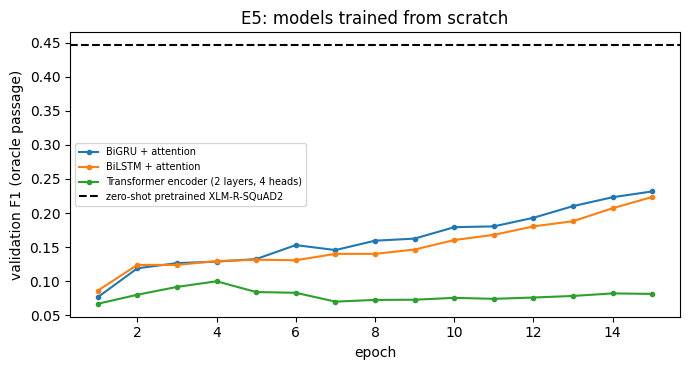

In [41]:
if e5_runs:
    summary = []
    for name, kind, lr in E5_CONFIGS:
        rs = [r for r in e5_runs if r["name"] == name]; f = lambda split, k: [r[split][k] for r in rs]
        summary.append({"name": name, "kind": kind, "lr": lr, "seeds": [r["seed"] for r in rs], "trainable_parameters": rs[0]["trainable_parameters"], "best_epochs": [r["best_epoch"] for r in rs],
                        "val_EM_mean": round(float(np.mean(f("val", "EM"))), 4), "val_F1_mean": round(float(np.mean(f("val", "F1"))), 4), "val_F1_std": round(float(np.std(f("val", "F1"))), 4),
                        "test_EM_mean": round(float(np.mean(f("test", "EM"))), 4), "test_F1_mean": round(float(np.mean(f("test", "F1"))), 4), "test_F1_std": round(float(np.std(f("test", "F1"))), 4)})
    save_json({"epochs": E5_EPOCHS, "vocabulary_size": len(vocab), "label_ceiling_val": {"EM": round(ceil_em, 4), "F1": round(ceil_f1, 4)}, "summary": summary,
               "runs": [{k: v for k, v in r.items() if k != "state"} for r in e5_runs]}, EXP / "e5_scratch.json")
    print(pd.DataFrame(summary)[["name", "trainable_parameters", "val_F1_mean", "val_F1_std", "test_EM_mean", "test_F1_mean", "test_F1_std"]].to_string(index=False))
    fig, ax = plt.subplots(figsize=(7, 3.8))
    for name, kind, lr in E5_CONFIGS:
        rs = [r for r in e5_runs if r["name"] == name]
        ax.plot(range(1, E5_EPOCHS + 1), np.mean([[c["val_F1"] for c in r["curve"]] for r in rs], axis=0), marker="o", ms=3, label=name)
    ax.axhline(zs_results["val"]["oracle_passage"]["F1"], color="k", ls="--", label="zero-shot pretrained XLM-R-SQuAD2")
    ax.set_xlabel("epoch"); ax.set_ylabel("validation F1 (oracle passage)"); ax.set_title("E5: models trained from scratch"); ax.legend(fontsize=7)
    plt.tight_layout(); plt.savefig(FIG / (("_smoke_" if SMOKE else "") + "e5_scratch_curves.png"), dpi=150); plt.show()

### 3.5c E6: the deployed model (best of the three) and its refusal rule
**Choice:** the single E5 run with the highest *validation* F1 becomes the deployed model. Its test score was already computed once at its best epoch and is not used to choose.

**Full pipeline for this model:** BM25 picks the top passage (as in Part 2), then the model reads it. We measure end-to-end EM/F1, and fit a refusal rule exactly as in E2, with two signals:
1. the normalised **BM25 score** of the best passage (how well the question matches the collection), and
2. the model's **span confidence**: the log-probability the model gives to its chosen start word and end word (each softmax taken over passage words). A model that is sure of where the answer is gives a high value; a model that spreads probability over many places gives a low value.

A logistic regression combines the two (fitted on validation only: in-domain = 1, out-of-domain = 0). The threshold keeps 95% of in-domain validation questions answered. The best of the three signals by validation AUROC is the deployed rule.

In [42]:
if e5_runs:
    best_run = max(e5_runs, key=lambda r: r["val"]["F1"])
    dep_model = build_model(best_run["kind"]).to(DEVICE); dep_model.load_state_dict(best_run["state"]); dep_model.eval()
    print(f"deployed model: {best_run['name']} (seed {best_run['seed']}, epoch {best_run['best_epoch']}) | validation F1 {best_run['val']['F1']} | test F1 {best_run['test']['F1']}")

    def dep_read(question, context):
        ids, seg, off, spans = encode_example(question, context, vocab)
        x = {"ids": ids, "seg": seg, "off": off, "spans": spans, "context": context}
        return decode_item(x, logits_for(dep_model, [x])[0])                                  # (answer text, log span probability)

    def bm25_signal(question):
        q = tok(question); s = bm25.scores(q); i = int(np.argsort(-s, kind="stable")[0])
        return pid_list[i], bm25.normalized_top_score(q, float(s[i]))

    DEP = {}
    for name, qs in (("val", val_p3), ("test", test_p3)):
        recs = []
        for q in qs:
            pid, bm = bm25_signal(q["question"]); text, conf = dep_read(q["question"], ctx_of[pid])
            recs.append({"pid": pid, "bm": bm, "text": text, "conf": conf})
        oo = []
        for q in ood_p3[name]:
            pid, bm = bm25_signal(q["question"]); text, conf = dep_read(q["question"], ctx_of[pid])
            oo.append({"pid": pid, "bm": bm, "text": text, "conf": conf})
        DEP[name] = {"in": recs, "ood": oo, "oracle": score_items(dep_model, enc_rows[name]),
                     "e2e": qa_scores(qs, [{"text": r["text"]} for r in recs]), "oracle_texts": [decode_item(x, lg)[0] for x, lg in zip(enc_rows[name], logits_for(dep_model, enc_rows[name]))]}
    print({s: {"oracle": DEP[s]["oracle"], "end_to_end": DEP[s]["e2e"]} for s in DEP})

deployed model: BiGRU + attention (seed 43, epoch 14) | validation F1 0.2938 | test F1 0.2992
{'val': {'oracle': {'EM': 0.1788, 'F1': 0.2938}, 'end_to_end': {'EM': 0.0879, 'F1': 0.188}}, 'test': {'oracle': {'EM': 0.1791, 'F1': 0.2992}, 'end_to_end': {'EM': 0.0776, 'F1': 0.1708}}}


In [43]:
if e5_runs:
    def sig_matrix(name):
        inn, oo = DEP[name]["in"], DEP[name]["ood"]
        X = np.c_[[r["bm"] for r in inn + oo], [r["conf"] for r in inn + oo]]
        return X, np.r_[np.ones(len(inn)), np.zeros(len(oo))], len(inn)
    Xv6, yv6, nv6 = sig_matrix("val"); Xt6, yt6, nt6 = sig_matrix("test")
    mu6, sd6 = Xv6.mean(0), Xv6.std(0)
    clf6 = LogisticRegression(class_weight="balanced", max_iter=1000).fit((Xv6 - mu6) / sd6, yv6)
    sig6 = {"BM25 score only": lambda X: X[:, 0], "model confidence only": lambda X: X[:, 1],
            "combined (logistic regression)": lambda X: clf6.decision_function((X - mu6) / sd6)}
    rows6, TAU6 = [], {}
    for sname, f in sig6.items():
        tau = float(np.quantile(f(Xv6)[:nv6], 0.05)); TAU6[sname] = tau
        row = {"signal": sname}
        for split_name, X, y, n_in in (("val", Xv6, yv6, nv6), ("test", Xt6, yt6, nt6)):
            s = f(X); row[f"AUROC {split_name}"] = round(float(roc_auc_score(y, s)), 4)
            row[f"in-domain answered {split_name}"] = round(float((s[:n_in] >= tau).mean()), 4)
            row[f"out-of-domain refused {split_name}"] = round(float((s[n_in:] < tau).mean()), 4)
        rows6.append(row)
    e6_df = pd.DataFrame(rows6); e6_df.to_csv(EXP / "e6_refusal_deployed.csv", index=False)
    E6_BEST = max(sig6, key=lambda s: e6_df.set_index("signal").loc[s, "AUROC val"])
    print("logistic regression weights on standardised [BM25 score, model confidence]:", clf6.coef_.round(3).tolist(), "| selected on validation AUROC:", E6_BEST)
    refusal6 = {"signal": E6_BEST, "threshold": TAU6[E6_BEST], "feature_mean": mu6.tolist(), "feature_std": sd6.tolist(),
                "lr_coef": clf6.coef_[0].tolist(), "lr_intercept": float(clf6.intercept_[0]), "features": ["normalized_bm25_top_score", "model_log_span_probability"]}
    save_json(refusal6, EXP / "refusal_config_deployed.json")

    # predictions in the same file format used by the error analysis (Part 4)
    for name, qs in (("val", val_p3), ("test", test_p3)):
        write_jsonl([{"id": q["id"], "question": q["question"], "gold_answer": q["answer"], "gold_pid": q["pid"], "retrieved_pid": r["pid"],
                      "pred_oracle": po, "pred_end_to_end": r["text"], "f1_oracle": round(f1_score(po, q["answer"]), 3), "f1_end_to_end": round(f1_score(r["text"], q["answer"]), 3),
                      "margin_end_to_end": round(r["conf"], 3)} for q, r, po in zip(qs, DEP[name]["in"], DEP[name]["oracle_texts"])], EXP / f"deployed_preds_{name}.jsonl")
    save_json({"model": best_run["name"], "seed": best_run["seed"], "best_epoch": best_run["best_epoch"], "trainable_parameters": best_run["trainable_parameters"],
               "chosen_by": "highest validation F1 (oracle passage) among the three architectures and all seeds",
               "val": {"oracle": DEP["val"]["oracle"], "end_to_end": DEP["val"]["e2e"]}, "test": {"oracle": DEP["test"]["oracle"], "end_to_end": DEP["test"]["e2e"]},
               "refusal": {"signal": E6_BEST, "threshold": TAU6[E6_BEST], "table_file": "e6_refusal_deployed.csv"}}, EXP / "deployed_model_metrics.json")
    e6_df.T

logistic regression weights on standardised [BM25 score, model confidence]: [[4.157, 0.079]] | selected on validation AUROC: combined (logistic regression)


### 3.6 All experiments in one table
Every number comes from files in `results/`. Systems are scored on the same validation and test questions. "Oracle" gives the reader the correct passage; "end-to-end" uses BM25's top-1 passage unless stated.

In [44]:
def fnum(x): return "" if x is None else f"{x:.3f}"
rows = []
B = json.loads((BASE / "metrics.json").read_text()); Z = json.loads((BASE / "zeroshot_metrics.json").read_text())
def add(system, setting, val_s, test_s, note=""):
    rows.append({"system": system, "setting": setting, "val EM": fnum(val_s["EM"]), "val F1": fnum(val_s["F1"]),
                 "test EM": fnum(test_s["EM"]), "test F1": fnum(test_s["F1"]), "note": note})
add("Rule-based reader", "oracle passage", B["results"]["val"]["oracle_passage"], B["results"]["test"]["oracle_passage"], "Part 2")
add("Rule-based reader", "BM25 top-1", B["results"]["val"]["end_to_end_bm25_top1"], B["results"]["test"]["end_to_end_bm25_top1"], "Part 2")
add("Zero-shot XLM-R-base-SQuAD2", "oracle passage", Z["val"]["oracle_passage"], Z["test"]["oracle_passage"], "Part 2")
add("Zero-shot XLM-R-base-SQuAD2", "BM25 top-1", Z["val"]["end_to_end_bm25_top1"], Z["test"]["end_to_end_bm25_top1"], "Part 2")
if (EXP / "e1_topk_reading.csv").exists():
    e1_file = pd.read_csv(EXP / "e1_topk_reading.csv")
    for k, rule in [(3, "span score"), (3, "margin"), (5, "span score"), (5, "margin")]:
        sel = lambda s: e1_file[(e1_file.split == s) & (e1_file.k == k) & (e1_file.choose_by == rule)]
        if len(sel("val")) and len(sel("test")):
            add("Zero-shot reader, top-k passages", f"BM25 top-{k}, choose by {rule}", sel("val").iloc[0], sel("test").iloc[0], "E1")
if (EXP / "e3_head_only.json").exists():
    e3 = json.loads((EXP / "e3_head_only.json").read_text())
    sel_grid = [g for g in e3["grid"] if g["lr"] == e3["selected_lr"]][0]
    add("Head-only fine-tuned (frozen encoder)", "oracle passage", {"EM": None, "F1": sel_grid["val_F1_mean"]},
        {"EM": e3["test_EM_mean"], "F1": e3["test_F1_mean"]}, f"E3, lr {e3['selected_lr']:g}, mean of 3 seeds (test F1 std {e3['test_F1_std']})")
if (EXP / "e5_scratch.json").exists():
    e5 = json.loads((EXP / "e5_scratch.json").read_text())
    for m in e5["summary"]:
        add(f"{m['name']} (trained from scratch)", "oracle passage", {"EM": m["val_EM_mean"], "F1": m["val_F1_mean"]}, {"EM": m["test_EM_mean"], "F1": m["test_F1_mean"]},
            f"E5, mean of {len(m['seeds'])} seed(s), test F1 std {m['test_F1_std']}")
if (EXP / "deployed_model_metrics.json").exists():
    dm = json.loads((EXP / "deployed_model_metrics.json").read_text())
    add(f"DEPLOYED: {dm['model']} (seed {dm['seed']})", "oracle passage", dm["val"]["oracle"], dm["test"]["oracle"], "E6, best single run by validation F1")
    add(f"DEPLOYED: {dm['model']} (seed {dm['seed']})", "BM25 top-1", dm["val"]["end_to_end"], dm["test"]["end_to_end"], "E6, what the web app runs")
for f in sorted(EXP.glob("ft_*.json")):
    r = json.loads(f.read_text())
    add(f"Full fine-tune {r['tag']}", "oracle passage", r["val"]["oracle_passage"], r["test"]["oracle_passage"], f"E4, {r['epochs']} epochs, lr {r['lr']:g}, seed {r['seed']}")
    add(f"Full fine-tune {r['tag']}", "BM25 top-1", r["val"]["end_to_end_bm25_top1"], r["test"]["end_to_end_bm25_top1"], "E4")
results_df = pd.DataFrame(rows); results_df.to_csv(EXP / "results_table.csv", index=False)
if not any(EXP.glob("ft_*.json")): print("NOTE: no full fine-tuning (E4) results yet. Run on Colab, then re-run this cell.")
results_df

,system,setting,val EM,val F1,test EM,test F1,note
0,Rule-based reader,oracle passage,0.000,0.105,0.003,0.093,Part 2
1,Rule-based reader,BM25 top-1,0.000,0.071,0.003,0.068,Part 2
2,Zero-shot XLM-R-base-SQuAD2,oracle passage,0.309,0.446,0.343,0.492,Part 2
3,Zero-shot XLM-R-base-SQuAD2,BM25 top-1,0.167,0.272,0.170,0.263,Part 2
4,"Zero-shot reader, top-k passages","BM25 top-3, choose by span score",0.221,0.321,0.221,0.326,E1
5,"Zero-shot reader, top-k passages","BM25 top-3, choose by margin",0.224,0.326,0.218,0.326,E1
6,"Zero-shot reader, top-k passages","BM25 top-5, choose by span score",0.233,0.342,0.221,0.338,E1
7,"Zero-shot reader, top-k passages","BM25 top-5, choose by margin",0.233,0.344,0.215,0.330,E1
8,Head-only fine-tuned (frozen encoder),oracle passage,,0.498,0.399,0.533,"E3, lr 0.001, mean of 3 seeds (test F1 std 0.0..."
9,BiGRU + attention (trained from scratch),oracle passage,0.140,0.237,0.133,0.236,"E5, mean of 3 seed(s), test F1 std 0.0563"


## Part 4. Final evaluation and error analysis (Phase 5)

**Which system is analysed?** The **deployed model** from E6 (best of the three from-scratch models by validation F1, reading BM25's top passage, with its refusal rule), because that is what the web app runs. If E5 was not run in this session (no GPU), the zero-shot pretrained system is analysed instead; the cell below prints which one. The pretrained zero-shot system is also categorised in the same way, so the two can be compared.

**Method.** Each test question is assigned exactly one outcome by fixed, documented rules, so the counts can be reproduced:

| Outcome | Rule (checked in this order) |
|---|---|
| exact match | normalised prediction equals normalised gold answer |
| retrieval failure | end-to-end only: BM25's top passage is not the passage the question was written from |
| no answer returned | prediction is empty |
| too long | prediction contains the gold answer plus extra words |
| too short | prediction is a part of the gold answer |
| partial overlap | shares words with the gold answer but neither contains the other (shifted boundary) |
| wrong span, right sentence | no word overlap; the prediction lies in the same sentence as the gold answer |
| wrong sentence | no word overlap; the prediction lies in a different sentence |

Sentences are split on `. ! ?`. The location of a prediction is found by searching for its text in the passage (first occurrence), so for very short predictions that repeat elsewhere the sentence label can be wrong. These categories describe *what* went wrong; the *causes* we offer in the report are hypotheses unless a test is stated.

English glosses come from the dataset's own English version of the data (translation method not verified by me), so use them as a reading aid, not as ground truth.

In [45]:
import csv, io
RAW_EN = RAW / "hortidata_english.csv"
EN = {}
try:
    ok = fetch(f"https://dataverse.harvard.edu/api/access/datafile/{files['hortidata_english.tab']['dataFile']['id']}?format=original", RAW_EN)
    if ok:
        EN = {int(r["id"]): r for r in csv.DictReader(io.StringIO(RAW_EN.read_bytes().decode("cp1252", errors="replace")))}
except Exception as e:
    print("English gloss file unavailable:", e)
print("English glosses loaded for", len(EN), "records")

ALL_ROWS = {r["id"]: r for r in train + val + test}
HAVE_DEP = bool(e5_runs)
PRED_ZS = {s: read_jsonl(BASE / f"zeroshot_predictions_{s}.jsonl") for s in ("val", "test")}     # pretrained zero-shot system, for comparison
if HAVE_DEP:
    analysed_name = f"Deployed model: {best_run['name']}"
    PRED = {s: read_jsonl(EXP / f"deployed_preds_{s}.jsonl") for s in ("val", "test")}
    test_used, ood_test_rows = test_p3, ood_p3["test"]
    f_sel = sig6[E6_BEST]; tau_sel = TAU6[E6_BEST]; sel_name = E6_BEST
    conf_all = f_sel(Xt6); conf_in, conf_out = conf_all[:nt6], conf_all[nt6:]
    ood_answers = [r["text"] for r in DEP["test"]["ood"]]
else:
    analysed_name = "Zero-shot XLM-R-base-SQuAD2 (E5 not run in this session)"
    PRED = PRED_ZS
    test_used, ood_test_rows = test, ood["test"]
    f_sel = sig[E2_BEST]; tau_sel = TAU[E2_BEST]; sel_name = E2_BEST
    conf_all = f_sel(Xt); conf_in, conf_out = conf_all[:nt], conf_all[nt:]
    ood_answers = [r["text"] for r in zs[("ood", "test")]]
print("system analysed:", analysed_name)

English glosses loaded for 2231 records
system analysed: Deployed model: BiGRU + attention


In [46]:
SPAN_RE = re.compile(r"[^.!?]+(?:[.!?]+|$)\s*")
def sentence_spans(ctx): return [(m.start(), m.end()) for m in SPAN_RE.finditer(ctx)] or [(0, len(ctx))]
def sentence_of(spans, pos):
    for i, (a, b) in enumerate(spans):
        if a <= pos < b: return i
    return len(spans) - 1

CATS = ["exact match", "retrieval failure (wrong passage)", "no answer returned", "too long (contains gold)", "too short (inside gold)",
        "partial overlap (shifted boundary)", "wrong span, right sentence", "wrong sentence"]

def categorize(p, setting):
    row = ALL_ROWS[p["id"]]; pred = p["pred_oracle"] if setting == "oracle" else p["pred_end_to_end"]
    gold = row["answer"]
    if exact_match(pred, gold): return "exact match"
    if setting == "e2e" and p["retrieved_pid"] != p["gold_pid"]: return "retrieval failure (wrong passage)"
    n_pred, n_gold = normalize_answer(pred), normalize_answer(gold)
    if not n_pred: return "no answer returned"
    if f1_score(pred, gold) > 0:
        if n_gold in n_pred: return "too long (contains gold)"
        if n_pred in n_gold: return "too short (inside gold)"
        return "partial overlap (shifted boundary)"
    spans = sentence_spans(row["context"]); loc = row["context"].find(pred)
    if loc < 0: return "wrong sentence"
    return "wrong span, right sentence" if sentence_of(spans, loc) == sentence_of(spans, row["answer_start"]) else "wrong sentence"

def category_table(pred_by_split):
    t = {(s, st): collections.Counter(categorize(p, st) for p in pred_by_split[s]) for s in ("val", "test") for st in ("oracle", "e2e")}
    df_ = pd.DataFrame({f"{s} {st}": [t[(s, st)].get(c, 0) for c in CATS] for s in ("val", "test") for st in ("oracle", "e2e")}, index=CATS)
    df_.loc["total"] = df_.sum(); return t, df_
cat_table, cat_df = category_table(PRED)
cat_table_zs, cat_df_zs = category_table(PRED_ZS)
cat_df.to_csv(EXP / "error_categories.csv"); cat_df_zs.to_csv(EXP / "error_categories_zero_shot.csv")
print(analysed_name); print(cat_df.to_string()); print("\nFor comparison, the pretrained zero-shot system:"); print(cat_df_zs.to_string())

Deployed model: BiGRU + attention
                                    val oracle  val e2e  test oracle  test e2e
exact match                                 59       29           60        26
retrieval failure (wrong passage)            0      146            0       181
no answer returned                           0        0            0         0
too long (contains gold)                    39       25           29        15
too short (inside gold)                      8        4           14         5
partial overlap (shifted boundary)          50       28           51        20
wrong span, right sentence                  30       14           32        15
wrong sentence                             144       84          149        73
total                                      330      330          335       335

For comparison, the pretrained zero-shot system:
                                    val oracle  val e2e  test oracle  test e2e
exact match                                102 

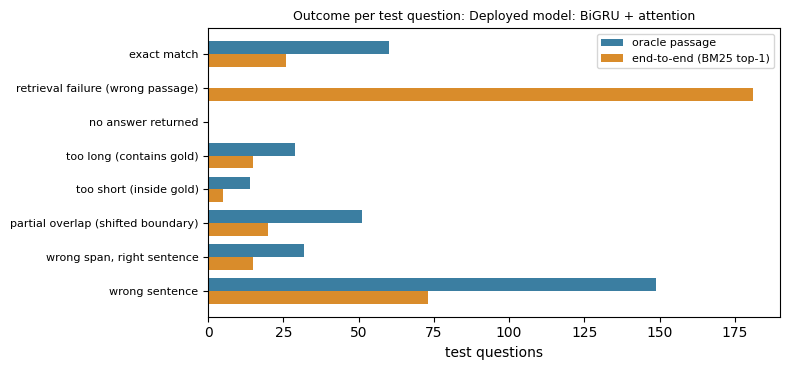

--- mean F1 by question word
group   n  F1 oracle  F1 end-to-end
 gani 366      0.337          0.214
other 120      0.206          0.091
   je  69      0.288          0.113
 nini  43      0.134          0.087
ngapi  35      0.427          0.331
 wapi  14      0.368          0.293
 lini   8      0.375          0.260
 vipi   7      0.000          0.029
 nani   3      0.167          0.167
--- mean F1 by gold answer length
    group   n  F1 oracle  F1 end-to-end
   1 word 104      0.168          0.103
2-3 words 312      0.296          0.173
4-6 words 197      0.357          0.230
 7+ words  52      0.327          0.178
--- mean F1 by passage length
         group   n  F1 oracle  F1 end-to-end
 short passage 156      0.284          0.171
medium passage 258      0.295          0.187
  long passage 251      0.306          0.176


In [47]:
fig, ax = plt.subplots(figsize=(8, 3.8))
y = np.arange(len(CATS)); w = 0.38
ax.barh(y - w / 2, [cat_table[("test", "oracle")].get(c, 0) for c in CATS], height=w, label="oracle passage", color="#3b7ea1")
ax.barh(y + w / 2, [cat_table[("test", "e2e")].get(c, 0) for c in CATS], height=w, label="end-to-end (BM25 top-1)", color="#d98c2b")
ax.set_yticks(y); ax.set_yticklabels(CATS, fontsize=8); ax.invert_yaxis(); ax.set_xlabel("test questions"); ax.legend(fontsize=8)
ax.set_title(f"Outcome per test question: {analysed_name}", fontsize=9)
plt.tight_layout(); plt.savefig(FIG / (("_smoke_" if SMOKE else "") + "error_categories.png"), dpi=150); plt.show()

# ---- where does quality vary? mean F1 by question word, answer length, passage length (validation + test pooled; nothing is selected here)
pooled = PRED["val"] + PRED["test"]
def qkw(q):
    for k, pat in QWORDS.items():
        if re.search(pat, q.lower()): return k
    return "other"
def breakdown(keyfn, order=None):
    g = collections.defaultdict(list)
    for p in pooled:
        row = ALL_ROWS[p["id"]]; g[keyfn(row)].append((p["f1_oracle"], p["f1_end_to_end"]))
    keys = order or sorted(g, key=lambda k: -len(g[k]))
    return pd.DataFrame([{"group": k, "n": len(g[k]), "F1 oracle": round(float(np.mean([a for a, b in g[k]])), 3), "F1 end-to-end": round(float(np.mean([b for a, b in g[k]])), 3)} for k in keys if k in g])
by_q = breakdown(lambda r: qkw(r["question"]))
by_a = breakdown(lambda r: "1 word" if len(words(r["answer"])) == 1 else "2-3 words" if len(words(r["answer"])) <= 3 else "4-6 words" if len(words(r["answer"])) <= 6 else "7+ words", ["1 word", "2-3 words", "4-6 words", "7+ words"])
plen = [len(words(r["context"])) for r in ALL_ROWS.values()]; q1, q2 = np.quantile(plen, [1 / 3, 2 / 3])
by_p = breakdown(lambda r: "short passage" if len(words(r["context"])) <= q1 else "medium passage" if len(words(r["context"])) <= q2 else "long passage", ["short passage", "medium passage", "long passage"])
for name, d_ in (("question word", by_q), ("gold answer length", by_a), ("passage length", by_p)):
    print(f"--- mean F1 by {name}"); print(d_.to_string(index=False))
by_q.to_csv(EXP / "f1_by_question_word.csv", index=False); by_a.to_csv(EXP / "f1_by_answer_length.csv", index=False); by_p.to_csv(EXP / "f1_by_passage_length.csv", index=False)

In [48]:
# ---- success and failure examples per category (first three by id, test set)
def gloss(p):
    r = EN.get(p["id"], {}); return (r.get("question", ""), r.get("answer", ""))
def examples(cat, setting="e2e", split_name="test", n=3):
    out = []
    for p in sorted(PRED[split_name], key=lambda p: p["id"]):
        if categorize(p, setting) == cat:
            qe, ae = gloss(p); pred = p["pred_oracle"] if setting == "oracle" else p["pred_end_to_end"]
            out.append({"id": p["id"], "question": p["question"], "question_en": qe, "gold": p["gold_answer"], "gold_en": ae, "pred": pred, "f1": p["f1_oracle"] if setting == "oracle" else p["f1_end_to_end"]})
        if len(out) == n: break
    return out

# ---- refusal analysis with the selected signal: who gets through, who is wrongly turned away
false_accepts = sorted([(float(c), i) for i, c in enumerate(conf_out) if c >= tau_sel], reverse=True)[:8]
false_refusals = sorted([(float(c), i) for i, c in enumerate(conf_in) if c < tau_sel])[:8]
print(f"signal: {sel_name} | threshold {tau_sel:.3f}: out-of-domain wrongly answered: {int((conf_out >= tau_sel).sum())}/{len(conf_out)}; in-domain wrongly refused: {int((conf_in < tau_sel).sum())}/{len(conf_in)}")
for c, i in false_accepts[:5]:
    print(f"  FALSE ACCEPT conf={c:.2f} | {ood_test_rows[i]['question']} | EN: {ood_test_rows[i]['english_translation']} | system answered: {ood_answers[i][:60]}")

signal: combined (logistic regression) | threshold -0.431: out-of-domain wrongly answered: 33/301; in-domain wrongly refused: 32/335
  FALSE ACCEPT conf=8.95 | Kuna aina ngapi ya minyoo? | EN: How many types of worms are there? | system answered: Pochonia chlamydosporia, Trichoderma spp. na Paecilomyces li
  FALSE ACCEPT conf=3.03 | Je dhahabu inapatika kwa wingi nchi gani Afrika? | EN: In which country in Africa is gold most abundant? | system answered: Marekani, Italia na Meksiko
  FALSE ACCEPT conf=2.99 | Tepu ni nini? | EN: What is Tepu? | system answered: kikonyo kilichokauka cha ua
  FALSE ACCEPT conf=2.47 | Jina Firigogo linatokana na nini? | EN: What is the origin of  the name Sandgrouse? | system answered: kikonyo kilichokauka cha ua
  FALSE ACCEPT conf=2.42 | Sultan wa kwanza wa Zanzibar anaitwaje? | EN: What is the name of the first sultan of Zanzibar? | system answered: kikonyo kilichokauka cha ua


In [49]:
# ---- bootstrap confidence intervals for the analysed system (resample test questions with replacement; seed 42)
def boot_ci(values, n=2000, seed=SEED):
    rng_ = np.random.default_rng(seed); v = np.asarray(values, dtype=float)
    means = [rng_.choice(v, len(v), replace=True).mean() for _ in range(n)]
    return round(float(v.mean()), 4), round(float(np.percentile(means, 2.5)), 4), round(float(np.percentile(means, 97.5)), 4)

T = PRED["test"]
final = {"system": analysed_name, "n_test_questions": len(T)}
final["oracle_EM"] = boot_ci([exact_match(p["pred_oracle"], p["gold_answer"]) for p in T])
final["oracle_F1"] = boot_ci([p["f1_oracle"] for p in T])
final["end_to_end_EM"] = boot_ci([exact_match(p["pred_end_to_end"], p["gold_answer"]) for p in T])
final["end_to_end_F1"] = boot_ci([p["f1_end_to_end"] for p in T])
final["retrieval_recall@1"] = boot_ci([float(p["retrieved_pid"] == p["gold_pid"]) for p in T])
rng_ = np.random.default_rng(SEED); aucs = []
for _ in range(1000):
    a = rng_.choice(conf_in, len(conf_in)); b = rng_.choice(conf_out, len(conf_out))
    aucs.append(roc_auc_score(np.r_[np.ones(len(a)), np.zeros(len(b))], np.r_[a, b]))
final["refusal_signal"] = sel_name
final["refusal_AUROC"] = (round(float(roc_auc_score(np.r_[np.ones(len(conf_in)), np.zeros(len(conf_out))], np.r_[conf_in, conf_out])), 4), round(float(np.percentile(aucs, 2.5)), 4), round(float(np.percentile(aucs, 97.5)), 4))
final["in_domain_answered"] = round(float((conf_in >= tau_sel).mean()), 4); final["out_of_domain_refused"] = round(float((conf_out < tau_sel).mean()), 4)
final["format"] = "(estimate, 95% CI low, 95% CI high)"
save_json(final, EXP / "final_test_evaluation.json")
print(json.dumps(final, indent=1))

{
 "system": "Deployed model: BiGRU + attention",
 "n_test_questions": 335,
 "oracle_EM": [
  0.1791,
  0.1373,
  0.2209
 ],
 "oracle_F1": [
  0.2992,
  0.2577,
  0.3423
 ],
 "end_to_end_EM": [
  0.0776,
  0.0507,
  0.1075
 ],
 "end_to_end_F1": [
  0.1708,
  0.1391,
  0.2047
 ],
 "retrieval_recall@1": [
  0.4597,
  0.4089,
  0.5134
 ],
 "refusal_signal": "combined (logistic regression)",
 "refusal_AUROC": [
  0.9635,
  0.9489,
  0.9748
 ],
 "in_domain_answered": 0.9045,
 "out_of_domain_refused": 0.8904,
 "format": "(estimate, 95% CI low, 95% CI high)"
}


In [50]:
# ---- write results/error_analysis.md (also used by the report and the video)
def md_rows(rows):
    return "\n".join(f"| {r['id']} | {r['question']} | {r['question_en']} | {r['gold']} | {r['gold_en']} | {r['pred']} | {r['f1']} |" for r in rows)
lines = [f"# Error analysis: {analysed_name}", "",
         "Generated by `notebooks/swahili_horticulture_qa.ipynb` (Part 4). Counts and examples are computed; the *causes* below are hypotheses unless a test is stated.", "",
         "## Outcome counts (questions)", "", md_table(cat_df.reset_index().rename(columns={"index": "outcome"})), "",
         "For comparison, the same categories for the pretrained zero-shot system (XLM-R-base-SQuAD2):", "", md_table(cat_df_zs.reset_index().rename(columns={"index": "outcome"})), "",
         "## Mean F1 by question word, answer length, passage length (validation + test pooled)", "",
         "**Question word**", "", md_table(by_q), "", "**Gold answer length**", "", md_table(by_a), "", "**Passage length**", "", md_table(by_p), "",
         "## Examples (test set; English columns are the dataset's own English version, translation method not verified)", ""]
for setting, label in (("e2e", "end-to-end"), ("oracle", "oracle passage")):
    for cat in CATS:
        ex = examples(cat, setting)
        if ex:
            lines += [f"### {label}: {cat}", "", "| id | question | question (EN) | gold | gold (EN) | prediction | F1 |", "|---|---|---|---|---|---|---|", md_rows(ex), ""]
lines += ["## Refusal (out-of-domain handling)", "", f"Signal: {sel_name}; threshold {tau_sel:.3f} (chosen on validation so 95% of in-domain validation questions are answered).", "",
          f"On test: {final['in_domain_answered']:.1%} of in-domain questions answered; {final['out_of_domain_refused']:.1%} of out-of-domain questions refused (AUROC {final['refusal_AUROC'][0]}, 95% CI {final['refusal_AUROC'][1]} to {final['refusal_AUROC'][2]}).", "",
          "### Out-of-domain questions the system wrongly answers (highest confidence first)", "", "| confidence | question | English translation | system answered |", "|---|---|---|---|"]
lines += [f"| {c:.2f} | {ood_test_rows[i]['question']} | {ood_test_rows[i]['english_translation']} | {ood_answers[i][:70]} |" for c, i in false_accepts]
lines += ["", "### In-domain questions the system wrongly refuses (lowest confidence first)", "", "| confidence | question | question (EN) | gold answer |", "|---|---|---|---|"]
for c, i in false_refusals:
    q = test_used[i]; lines.append(f"| {c:.2f} | {q['question']} | {EN.get(q['id'], {}).get('question', '')} | {q['answer']} |")
out_path = EXP.parent / ("_smoke_error_analysis.md" if SMOKE else "error_analysis.md")
out_path.write_text("\n".join(lines) + "\n", encoding="utf-8"); print("wrote", out_path)

wrote /content/drive/MyDrive/ML_technique_1/Summative/results/error_analysis.md


## Part 5. Deployment: export the model to `model.pkl` and test the app code (Phase 6)

The web app (`app/streamlit_app.py`) is **self-contained and needs no deep-learning library**:
- **`app/model.pkl`** holds the deployed model: the network's weights as plain arrays (stored as bytes), the vocabulary, the architecture settings, and the refusal rule with its threshold. It contains only plain Python data, never custom classes.
- **`app/qa_pipeline.py`** re-implements the network's forward pass in NumPy (embeddings, GRU or LSTM or Transformer layers, attention) and runs BM25 retrieval, so the Streamlit app only needs `streamlit` and `numpy`.
- **`app/passages.jsonl`** is the 307-passage collection the app searches (from the CC0 dataset).

**What this part checks, because exporting a model by hand can fail silently:**
1. The NumPy network gives the **same scores as the PyTorch network** it was exported from (maximum difference printed).
2. The app code gives the **same retrieved passages, answers and answer/decline decisions** as the notebook on real validation questions.
3. A `model.pkl` that tries to run code when loaded is **rejected** by the app's loader.
4. The app handles **10+ varied inputs**, including edge cases, without crashing.

**Pickle safety.** Pickle can execute code when loading a tampered file. The app's loader (`load_bundle`) refuses every class or function lookup, so only plain data loads. Only use a `model.pkl` that you made yourself.

In [51]:
import pickle
APP = ROOT / "app"
if HAVE_DEP:
    out_dir = (ROOT / "results" / "_smoke") if SMOKE else APP
    out_dir.mkdir(parents=True, exist_ok=True)
    pkl_path, pass_path = out_dir / ("model_smoke.pkl" if SMOKE else "model.pkl"), out_dir / ("app_passages.jsonl" if SMOKE else "passages.jsonl")

    ok_in = [p["question"] for p, c in zip(PRED["test"], conf_in) if c >= tau_sel and exact_match(p["pred_end_to_end"], p["gold_answer"])][:4]    # answered correctly
    ok_out = [ood_test_rows[i]["question"] for i, c in enumerate(conf_out) if c < tau_sel][:2]                                                    # out of domain, declined
    bundle = {"format_version": 1, "arch": ARCH[best_run["kind"]],
              "weights": {k: {"shape": list(v.shape), "dtype": "float32", "data": v.numpy().astype(np.float32).tobytes()} for k, v in best_run["state"].items()},
              "vocab": vocab, "special_ids": {"pad": PAD_ID, "unk": UNK_ID, "sep": SEP_ID}, "max_answer_words": MAX_ANS_WORDS,
              "retrieval": {"stem_k": BEST_K, "k1": 1.5, "b": 0.75}, "refusal": refusal6, "examples": ok_in + ok_out,
              "training": {"name": best_run["name"], "seed": best_run["seed"], "best_epoch": best_run["best_epoch"], "epochs": E5_EPOCHS,
                           "parameters": best_run["trainable_parameters"], "val_F1_oracle": best_run["val"]["F1"], "test_F1_oracle": best_run["test"]["F1"]},
              "note": "Written by notebooks/swahili_horticulture_qa.ipynb (Part 5). Plain data only; load with qa_pipeline.load_bundle."}
    with open(pkl_path, "wb") as f:
        pickle.dump(bundle, f, protocol=4)                       # protocol 4 stores bytes without any class references
    write_jsonl([{"pid": p["pid"], "context": p["context"]} for p in corpus], pass_path)
    print(f"wrote {pkl_path} ({pkl_path.stat().st_size / 1e6:.1f} MB) and {pass_path}")
    print("deployed model:", bundle["training"]); print("examples:", bundle["examples"])
else:
    print("E5 was not run in this session, so there is no deployed model to export. Run on Colab (GPU), then re-run from here.")
APP_CODE_PRESENT = HAVE_DEP and (APP / "qa_pipeline.py").exists()
if HAVE_DEP and not APP_CODE_PRESENT:
    print("app/qa_pipeline.py was not found next to the notebook, so the app tests are SKIPPED. "
          "Upload the app/ folder into the project folder and re-run from this cell to run them.")

wrote /content/drive/MyDrive/ML_technique_1/Summative/app/model.pkl (6.1 MB) and /content/drive/MyDrive/ML_technique_1/Summative/app/passages.jsonl
deployed model: {'name': 'BiGRU + attention', 'seed': 43, 'best_epoch': 14, 'epochs': 15, 'parameters': 1501698, 'val_F1_oracle': 0.2938, 'test_F1_oracle': 0.2992}
examples: ['Je, inachukua muda gani kutoka kupanda hadi kuvuna bamia?', 'Bamia changa zinakua na urefu gani?', 'Mavuno ya bamia yanaweza rudiwa baada ya muda gani?', 'Nafasi kati ya shimo na shimo la mimea ya giligilani inatakiwa kuwa ngapi?', 'Musikari Nazi Kombo anahudumu kama mbunge wa kuteuliwa katika eneo gani?', 'Chama cha FORD-Kenya kilianzishwa na nani?']
app/qa_pipeline.py was not found next to the notebook, so the app tests are SKIPPED. Upload the app/ folder into the project folder and re-run from this cell to run them.


In [52]:
if APP_CODE_PRESENT:
    import importlib
    sys.path.insert(0, str(APP))
    import qa_pipeline; importlib.reload(qa_pipeline)
    qa_app = qa_pipeline.SwahiliHorticultureQA(bundle_path=pkl_path, passages_path=pass_path)

    # (1) the NumPy network must give the same scores as the PyTorch network it was exported from
    diffs = []
    for q in val_p3[:10]:
        ctx = ctx_of[q["pid"]]
        ids, seg, off, spans = qa_app.encode(q["question"], ctx)
        lg_np = qa_app.reader.logits(ids, seg)
        lg_torch = logits_for(dep_model, [{"ids": ids, "seg": seg, "off": off, "spans": spans, "context": ctx}])[0]
        diffs.append(float(np.abs(lg_np - lg_torch).max()))
    print(f"largest difference between the NumPy and PyTorch scores on 10 passages: {max(diffs):.2e}")
    assert max(diffs) < 5e-3, "the NumPy network does not reproduce the PyTorch network"

    # (1b) ...and for ALL THREE architectures, not only the winner: whichever model wins on a future run must already be known to export correctly
    for kind in ("gru", "lstm", "transformer"):
        r_ = next((r for r in e5_runs if r["kind"] == kind), None)
        if r_ is None:
            continue
        m_ = build_model(kind).to(DEVICE); m_.load_state_dict(r_["state"]); m_.eval()
        reader_ = qa_pipeline.NumpyReader({"arch": ARCH[kind], "weights": {k: {"shape": list(v.shape), "dtype": "float32", "data": v.numpy().astype(np.float32).tobytes()} for k, v in r_["state"].items()}})
        worst = 0.0
        for q in val_p3[:5]:
            ctx = ctx_of[q["pid"]]; ids, seg, off, spans = qa_app.encode(q["question"], ctx)
            lg_t = logits_for(m_, [{"ids": ids, "seg": seg, "off": off, "spans": spans, "context": ctx}])[0]
            worst = max(worst, float(np.abs(reader_.logits(ids, seg) - lg_t).max()))
        print(f"  {kind}: largest NumPy vs PyTorch difference {worst:.2e}")
        assert worst < 5e-3, f"the NumPy {kind} network does not reproduce the PyTorch network"

    # (2) same retrieval, answers and answer/decline decisions as the notebook
    sample = list(zip(val_p3[:25], DEP["val"]["in"][:25]))
    same_pid = sum(qa_app.retrieve(q["question"])[0] == r["pid"] for q, r in sample)
    same_text = sum(qa_app.read(q["question"], ctx_of[r["pid"]])[0] == r["text"] for q, r in sample)
    tau = refusal6["threshold"]
    same_decision = sum((qa_app.answer(q["question"])["status"] == "answered") == (float(sig6[E6_BEST](np.array([[r["bm"], r["conf"]]]))[0]) >= tau) for q, r in sample)
    print(f"app matches the notebook on {same_pid}/{len(sample)} retrieved passages, {same_text}/{len(sample)} answers, {same_decision}/{len(sample)} answer-or-decline decisions")
    assert same_pid == len(sample) and same_text >= len(sample) - 1 and same_decision >= len(sample) - 1, "the app does not reproduce the evaluated system"

    # (3) a model.pkl that tries to run code must be rejected, not executed
    class _Evil:
        def __reduce__(self): return (print, ("THIS SHOULD NEVER BE PRINTED",))
    evil_path = pkl_path.with_name("evil_test.pkl"); evil_path.write_bytes(pickle.dumps({"x": _Evil()}, protocol=4))
    try:
        qa_pipeline.load_bundle(evil_path); raise AssertionError("an unsafe pickle was loaded")
    except pickle.UnpicklingError as e:
        print("unsafe pickle rejected:", str(e)[:90])
    finally:
        evil_path.unlink()

In [53]:
if APP_CODE_PRESENT:
    # (4) 10+ varied inputs, including edge cases. Glosses for the Swahili inputs I wrote myself are mine and should be checked by a Swahili speaker.
    tests = ([("in-domain (test question)", t, "") for t in ok_in[:3]] + [("out-of-domain (AfriQA trivia)", t, "") for t in ok_out[:2]] + [
        ("in-domain, written by me", "Mikoa gani inafaa kwa kilimo cha tufaa?", "Which regions suit growing apples?"),
        ("near-domain (livestock), written by me", "Ng'ombe wa maziwa wanahitaji chakula gani?", "What food do dairy cows need?"),
        ("near-domain (weather), written by me", "Hali ya hewa ikoje Dodoma leo?", "How is the weather in Dodoma today?"),
        ("English question about apples", "How do I grow apples?", ""),
        ("one-word query", "Tufaa", "Apple"),
        ("empty input", "", ""), ("whitespace only", "   ", ""), ("punctuation only", "????", ""),
        ("gibberish", "asdfghjkl qwerty zxcv", ""), ("numbers only", "12345", ""),
        ("very long input", "Je, tufaa hustawi wapi? " * 80, "The apple question repeated 80 times"),
    ])
    rows_out = []
    for cat, text, en in tests:
        t0_ = time.time(); r = qa_app.answer(text); dt = time.time() - t0_
        rows_out.append({"category": cat, "input": (text[:70] + "...") if len(text) > 70 else text, "english": en, "status": r["status"],
                         "answer": r.get("answer", ""), "confidence": r.get("confidence", ""), "seconds": round(dt, 2)})
    tests_df = pd.DataFrame(rows_out); tests_df.to_csv(EXP / "app_tests.csv", index=False)
    (EXP.parent / ("_smoke_app_tests.md" if SMOKE else "app_tests.md")).write_text("# Web app pipeline tests\n\nGenerated by notebook Part 5. Glosses for inputs I wrote are mine and unverified.\n\n" + md_table(tests_df) + "\n", encoding="utf-8")
    assert [r["status"] for r in rows_out if r["category"] in ("empty input", "whitespace only", "punctuation only")] == ["invalid"] * 3, "edge cases must be reported as invalid"
    assert all(r["status"] in ("answered", "declined", "invalid") for r in rows_out), "unexpected status"
    print(tests_df.drop(columns=["english"]).to_string(index=False))

### Run the app yourself
```
cd app
pip install -r requirements.txt
streamlit run streamlit_app.py
```
Then open the local address Streamlit prints. To get a **public link**, follow `app/README.md` (Streamlit Community Cloud, free, deploys from a public GitHub repository). **Publishing is public and uses your accounts, so I have not done it for you.** After deploying, paste the URL into the README and the report and test it with the same inputs as the table above.

In [54]:
# On Google Colab only: bundle everything this notebook produced so you can download it in one click.
if "google.colab" in sys.modules:
    import shutil
    from google.colab import files
    shutil.make_archive("/content/outputs", "zip", root_dir=str(ROOT), base_dir="results")      # all metrics, figures, predictions
    extra = [p for p in ("app/model.pkl", "app/passages.jsonl") if (ROOT / p).exists()]
    if extra:
        subprocess.run(["zip", "-q", "/content/outputs.zip", *extra], cwd=str(ROOT))
    files.download("/content/outputs.zip")
else:
    print("Not on Colab: results are already in", ROOT / "results")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Extra figure: E4 training curves
Plots the per-epoch training loss and validation F1 of every full fine-tuning run from the saved `results/experiments/ft_*.json` files (no retraining). Added after the Colab run; running it needs only the results folder.

In [ ]:
# E4 training curves from the saved runs (no retraining)
runs = [json.loads(f.read_text(encoding="utf-8")) for f in sorted((ROOT / "results" / "experiments").glob("ft_*.json"))]
if runs:
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
    for r in runs:
        ep = [c["epoch"] for c in r["curve"]]
        ax[0].plot(ep, [c["train_loss"] for c in r["curve"]], marker="o", ms=3, label=r["tag"])
        ax[1].plot(ep, [c["val_F1"] for c in r["curve"]], marker="o", ms=3, label=r["tag"])
    ax[0].set_xlabel("epoch"); ax[0].set_ylabel("training loss"); ax[0].set_title("E4: training loss")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation F1 (oracle passage)"); ax[1].set_title("E4: validation F1"); ax[1].legend(fontsize=6)
    ax[0].set_xticks(ep); ax[1].set_xticks(ep)
    plt.tight_layout(); plt.savefig(ROOT / "results" / "figures" / "e4_finetune_curves.png", dpi=150); plt.show()
else:
    print("no full fine-tuning results found")

### Extra analysis: Swahili word-prefix variants
The prefix stemmer (Part 2.1) keeps the first k letters of a word. In Swahili, noun-class prefixes (for example *m-*, *mi-*, *ma-*) sit at the start of words, so truncating keeps them instead of removing them. This cell counts, in the cleaned data, how often the passages and the questions use different prefixed forms of the same word, for the two crops with the most questions. It only counts words (no training) and saves `results/data/prefix_variants.json`.

In [ ]:
# Extra analysis: do prefix variants of the same Swahili word defeat a first-k-letters stemmer? (counts only, no training)
def variant_table(root_word, k=6):
    pc = collections.Counter(w.lower() for p in read_jsonl(PROC / "passages.jsonl") for w in WORD.findall(p["context"]))
    qc = collections.Counter(w.lower() for f in ("train", "val", "test") for r in read_jsonl(PROC / f"horti_{f}.jsonl") for w in WORD.findall(r["question"]))
    return [{"word": w, "in_passages": pc[w], "in_questions": qc[w], "first_6_letters": w[:k]} for w in sorted({x for x in list(pc) + list(qc) if root_word in x})]
variants = {root: variant_table(root) for root in ("vanila", "tufaa")}
save_json(variants, RES / "prefix_variants.json")
for root, rows in variants.items():
    print(root, [(r["word"], r["in_passages"], r["in_questions"], r["first_6_letters"]) for r in rows])